# PNAD — análise exploratória, desigualdade e validação externa

This notebook takes the refined datasets produced by notebook `01` and performs only the analytical layer. Scope: annual data validation; descriptive statistics; log-log histograms; empirical CCDF on a log-log scale; the transformation $\ln[\ln(100,\mathrm{CCDF})]$; statistics based on geometric bins; Lorenz curves; Gini, Pietra, Kolkata, and Zanardi indices; income shares of the top 10%, 1%, and 0.1%; temporal evolution of the indicators; and external validation of the Gini coefficient against IPEA and World Bank data. No manual outlier trimming is applied. Gompertz--Pareto, Pareto, MLE, and LS fitting are outside the scope of this notebook.


# Functions

In [1]:
from pathlib import Path
import re
import unicodedata
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

pd.set_option('display.max_columns', None)

PROJECT_PATH = Path(r"C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz")
METADATA_PATH = PROJECT_PATH / "metadata" / "df_metadata.xlsx"
REFINED_PATH = PROJECT_PATH / "dados_trusted"
TRUSTED_PATH = PROJECT_PATH / "dados_trusted" / "series_ipea_banco_mundial.csv"
ASSETS_PATH = PROJECT_PATH / "assets"
DATA_ASSETS_PATH = ASSETS_PATH / "data"
FIGURES_PATH = ASSETS_PATH / "figures"
DATA_ASSETS_PATH.mkdir(parents=True, exist_ok=True)
FIGURES_PATH.mkdir(parents=True, exist_ok=True)
BIN_RATIO = 1.05
LORENZ_GRID_SIZE = 1001
PLOT_COLS = 3
assert METADATA_PATH.is_file(), f"Metadata não encontrado: {METADATA_PATH}"
assert REFINED_PATH.is_dir(), f"Pasta refinada não encontrada: {REFINED_PATH}"
assert TRUSTED_PATH.is_file(), f"Série externa não encontrada: {TRUSTED_PATH}"


def geometric_edges(xmin, xmax, ratio=1.05):
    if xmin <= 0 or xmax <= 0 or xmax < xmin:
        raise ValueError(f"Intervalo inválido: xmin={xmin}, xmax={xmax}")
    if np.isclose(xmin, xmax):
        return np.array([xmin, xmin * ratio], dtype=float)
    n = int(np.ceil(np.log(xmax / xmin) / np.log(ratio)))
    edges = xmin * ratio ** np.arange(n + 1, dtype=float)
    if edges[-1] <= xmax:
        edges = np.append(edges, edges[-1] * ratio)
    return edges

def empirical_ccdf(values, thresholds):
    x = np.sort(np.asarray(values, dtype=float))
    t = np.asarray(thresholds, dtype=float)
    idx = np.searchsorted(x, t, side="left")
    return (x.size - idx) / x.size

def lorenz_curve(values):
    x = np.sort(np.asarray(values, dtype=float))
    if x.size == 0 or np.any(x < 0) or x.sum() <= 0:
        raise ValueError("Lorenz requer renda não negativa e soma positiva.")
    p = np.arange(1, x.size + 1, dtype=float) / x.size
    L = np.cumsum(x) / x.sum()
    return np.insert(p, 0, 0.0), np.insert(L, 0, 0.0)

def inequality_geometry(p, L):
    p = np.asarray(p, float); L = np.asarray(L, float)
    G = 1.0 - 2.0 * np.trapezoid(L, p)
    d = p - L
    ip = int(np.argmax(d))
    P = float(d[ip])
    f = L + p - 1.0
    crossing = np.where(np.signbit(f[:-1]) != np.signbit(f[1:]))[0]
    if crossing.size:
        i = int(crossing[0]); x0,x1=p[i],p[i+1]; y0,y1=f[i],f[i+1]
        k = float(x0 if np.isclose(y0,y1) else x0 - y0*(x1-x0)/(y1-y0))
    else:
        k = float(p[np.argmin(np.abs(f))])
    pp = 100*p; LL = 100*L; kp = 100*k
    corner = ((100-kp)**2)/2
    left = pp <= kp; right = pp >= kp
    B1 = np.trapezoid(LL[left], pp[left]) + corner
    B2 = np.trapezoid(LL[right], pp[right]) - corner
    G1 = (2500-B1)/2500; G2=(2500-B2)/2500
    Z = np.nan if np.isclose(G,0) else kp*(100-kp)*(G2-G1)/(10000*G)
    return {"Gini":float(G), "Pietra":P, "Pietra_x":float(p[ip]), "Pietra_y":float(L[ip]),
            "Kolkata":k, "Kolkata_pct":kp, "Zanardi":float(Z)}

def top_share(p, L, cutoff):
    return float(1.0 - np.interp(cutoff, p, L))

def geometric_mean_positive(values):
    x = np.asarray(values, float); x=x[x>0]
    return np.nan if x.size==0 else float(np.exp(np.mean(np.log(x))))


def make_grid(
    n,
    cols=4,
    figsize=None,
    width_per_col=4.2,
    height_per_row=3.4,
    sharex=False,
    sharey=False,
):
    """
    Create a subplot grid.

    Parameters
    ----------
    n : int
        Number of panels.
    cols : int, default=4
        Number of columns.
    figsize : tuple or None
        Total figure size. When None, it is calculated from the number
        of rows and columns.
    width_per_col, height_per_row : float
        Default panel dimensions used when figsize is None.
    sharex, sharey : bool
        Matplotlib shared-axis options.
    """
    rows = int(np.ceil(n / cols))

    if figsize is None:
        figsize = (
            width_per_col * cols,
            height_per_row * rows,
        )

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=figsize,
        squeeze=False,
        sharex=sharex,
        sharey=sharey,
    )

    return fig, axes


def finish_grid(fig, axes, n_used, suptitle, path, dpi=250):
    rows, cols = axes.shape

    for j in range(n_used, rows * cols):
        row, col = divmod(j, cols)
        fig.delaxes(axes[row, col])

    fig.suptitle(suptitle, fontsize=18, y=0.998)
    fig.tight_layout(rect=[0, 0, 1, 0.985])
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.show()


def norm_col(name):
    s=unicodedata.normalize("NFKD",str(name)); s="".join(c for c in s if not unicodedata.combining(c))
    return re.sub(r"[^a-z0-9]+","_",s.lower().strip()).strip("_")

def pick(cols,cands):
    return next((c for c in cands if c in cols),None)

def gini_scale(s):
    x=pd.to_numeric(s,errors="coerce"); finite=x[np.isfinite(x)]
    return x/100.0 if (not finite.empty and finite.max()>1.5) else x

def load_trusted(path):
    t=pd.read_csv(path,sep=None,engine="python").copy(); t.columns=[norm_col(c) for c in t.columns]
    cols=set(t.columns); y=pick(cols,["year","ano"])
    if y is None: raise ValueError(f"Coluna de ano não identificada. Colunas: {sorted(cols)}")
    ipea=pick(cols,["ipea","gini_ipea","serie_ipea","ipeadata"])
    wb=pick(cols,["banco_mundial","gini_banco_mundial","serie_banco_mundial","world_bank","worldbank","wb"])
    if ipea is not None or wb is not None:
        out=pd.DataFrame({"year":pd.to_numeric(t[y],errors="coerce")})
        if ipea is not None: out["IPEA"]=gini_scale(t[ipea])
        if wb is not None: out["Banco_Mundial"]=gini_scale(t[wb])
        out=out.dropna(subset=["year"]); out["year"]=out["year"].astype(int); return out
    src=pick(cols,["source","fonte","serie"]); val=pick(cols,["value","valor","gini"])
    if src is not None and val is not None:
        q=t[[y,src,val]].copy(); q[y]=pd.to_numeric(q[y],errors="coerce"); q[val]=gini_scale(q[val]); q[src]=q[src].astype(str).str.lower()
        q["source_norm"]=np.where(q[src].str.contains("ipea",na=False),"IPEA",np.where(q[src].str.contains("banco|world|bank",regex=True,na=False),"Banco_Mundial",np.nan))
        q=q.dropna(subset=[y,"source_norm"]); out=q.pivot_table(index=y,columns="source_norm",values=val,aggfunc="first").reset_index().rename(columns={y:"year"})
        out["year"]=out["year"].astype(int); out.columns.name=None; return out
    raise ValueError(f"Formato do CSV trusted não reconhecido. Colunas: {sorted(cols)}")







## Input and pipeline functions

In [2]:
# ---------------------------------------------------------------------
# Input and pipeline functions
# ---------------------------------------------------------------------

def year_from_filename(path):
    """Extract the four-digit year from a refined PNAD filename."""
    match = re.search(r"(\d{4})$", path.stem)
    if not match:
        raise ValueError(f"Ano não identificado em {path.name}")
    return int(match.group(1))


def load_inputs(metadata_path, refined_path):
    """Load metadata and discover all refined PNAD Parquet files."""
    df_metadata = pd.read_excel(metadata_path)

    required = {"ano", "Exchange", "Inflation"}
    missing = required - set(df_metadata.columns)
    if missing:
        raise ValueError(
            "Colunas ausentes no metadata: " + ", ".join(sorted(missing))
        )

    df_metadata = df_metadata.copy()
    df_metadata["ano"] = df_metadata["ano"].astype(int)

    files_by_year = {
        year_from_filename(path): path
        for path in refined_path.glob("pnad_trusted_*.parquet")
    }
    years = sorted(files_by_year)

    if not years:
        raise RuntimeError(f"Nenhum parquet encontrado em {refined_path}")

    missing_years = [
        year for year in years
        if year not in set(df_metadata["ano"])
    ]
    if missing_years:
        raise ValueError(f"Anos sem metadata: {missing_years}")

    return df_metadata, files_by_year, years


def analyze_year(year, parquet_path, metadata_row, bin_ratio, lorenz_grid_size):
    """Compute all tabular analytical objects for one PNAD year."""
    df = pd.read_parquet(parquet_path)

    if "renda" not in df.columns:
        raise ValueError(f"{year}: coluna renda ausente")

    # Convert the refined income column to a numeric array.
    nominal = pd.to_numeric(df["renda"], errors="coerce").to_numpy(float)

    n_total = nominal.size
    n_nan = int(np.isnan(nominal).sum())
    valid = nominal[np.isfinite(nominal)]
    n_zero = int(np.sum(valid == 0))
    n_negative = int(np.sum(valid < 0))

    if valid.size == 0:
        raise ValueError(f"{year}: nenhuma renda válida")
    if n_negative > 0:
        raise ValueError(f"{year}: {n_negative} rendas negativas")

    positive = valid[valid > 0]
    if positive.size == 0:
        raise ValueError(f"{year}: nenhuma renda positiva")

    # Convert nominal income to the common 2025 USD scale using metadata.
    exchange = float(metadata_row["Exchange"])
    inflation = float(metadata_row["Inflation"])

    if not np.isfinite(exchange) or exchange <= 0:
        raise ValueError(f"{year}: Exchange inválido")
    if not np.isfinite(inflation) or inflation <= 0:
        raise ValueError(f"{year}: Inflation inválido")

    adjusted = valid / exchange * inflation
    positive_adjusted = adjusted[adjusted > 0]

    xmin = float(positive_adjusted.min())
    xmax = float(positive_adjusted.max())

    # Use one geometric grid for CCDF thresholds and bin statistics.
    edges = geometric_edges(xmin, xmax, bin_ratio)
    thresholds = edges[:-1]

    ccdf = empirical_ccdf(adjusted, thresholds)
    ccdf_pct = 100 * ccdf

    # The double-log transform is real only where 100*CCDF > 1.
    lnln = np.full_like(ccdf_pct, np.nan, float)
    mask = ccdf_pct > 1
    lnln[mask] = np.log(np.log(ccdf_pct[mask]))

    ccdf_records = []
    for x, c, cp, ll in zip(thresholds, ccdf, ccdf_pct, lnln):
        ccdf_records.append({
            "year": year,
            "x": float(x),
            "ccdf": float(c),
            "ccdf_pct": float(cp),
            "ln_ln_ccdf_pct": float(ll) if np.isfinite(ll) else np.nan,
        })

    # Compute descriptive statistics inside each non-empty geometric bin.
    bins_records = []
    for i in range(len(edges) - 1):
        left, right = edges[i], edges[i + 1]
        mask_bin = (
            (positive_adjusted >= left)
            & (
                (positive_adjusted <= right)
                if i == len(edges) - 2
                else (positive_adjusted < right)
            )
        )
        values_bin = positive_adjusted[mask_bin]

        if values_bin.size == 0:
            continue

        bins_records.append({
            "year": year,
            "bin_left": float(left),
            "bin_right": float(right),
            "bin_center_geo": float(np.sqrt(left * right)),
            "N_bin": int(values_bin.size),
            "mean": float(np.mean(values_bin)),
            "geometric_mean": geometric_mean_positive(values_bin),
            "median": float(np.median(values_bin)),
            "std": (
                float(np.std(values_bin, ddof=1))
                if values_bin.size > 1
                else np.nan
            ),
            "ccdf": float(empirical_ccdf(adjusted, np.array([left]))[0]),
        })

    # Compute Lorenz curve and the inequality indices derived from it.
    population, income_share = lorenz_curve(adjusted)
    indices = inequality_geometry(population, income_share)

    lorenz_grid = np.linspace(0.0, 1.0, lorenz_grid_size)
    sampled_income = np.interp(lorenz_grid, population, income_share)

    lorenz_records = [
        {
            "year": year,
            "population_share": float(p),
            "income_share": float(L),
        }
        for p, L in zip(lorenz_grid, sampled_income)
    ]

    stats_record = {
        "year": year,
        "N": int(n_total),
        "N_valid": int(valid.size),
        "n_nan": n_nan,
        "n_zero": n_zero,
        "n_negative": n_negative,
        "xmin_positive_nominal": float(positive.min()),
        "xmax_nominal": float(valid.max()),
        "mean_nominal": float(np.mean(valid)),
        "median_nominal": float(np.median(valid)),
        "std_nominal": float(np.std(valid, ddof=1)) if valid.size > 1 else np.nan,
        "income_sum_nominal": float(np.sum(valid)),
        "xmin_positive": xmin,
        "xmax": xmax,
        "mean": float(np.mean(adjusted)),
        "median": float(np.median(adjusted)),
        "std": float(np.std(adjusted, ddof=1)) if adjusted.size > 1 else np.nan,
        "income_sum": float(np.sum(adjusted)),
        "Gini": indices["Gini"],
        "Pietra": indices["Pietra"],
        "Kolkata": indices["Kolkata"],
        "Kolkata_pct": indices["Kolkata_pct"],
        "Zanardi": indices["Zanardi"],
        "top_10": top_share(population, income_share, 0.90),
        "top_1": top_share(population, income_share, 0.99),
        "top_01": top_share(population, income_share, 0.999),
    }

    return stats_record, ccdf_records, bins_records, lorenz_records


def pipeline(metadata_path, refined_path, bin_ratio=1.05, lorenz_grid_size=1001):
    """Run the analytical preprocessing and return all core DataFrames."""
    df_metadata, files_by_year, years = load_inputs(metadata_path, refined_path)
    metadata_index = df_metadata.set_index("ano")

    stats_records = []
    ccdf_records = []
    bins_records = []
    lorenz_records = []

    for year in tqdm(years, desc="Analisando PNAD", unit="ano"):
        stats, ccdf, bins, lorenz = analyze_year(
            year=year,
            parquet_path=files_by_year[year],
            metadata_row=metadata_index.loc[year],
            bin_ratio=bin_ratio,
            lorenz_grid_size=lorenz_grid_size,
        )

        stats_records.append(stats)
        ccdf_records.extend(ccdf)
        bins_records.extend(bins)
        lorenz_records.extend(lorenz)

    return {
        "df_metadata": df_metadata,
        "files_by_year": files_by_year,
        "years": years,
        "df_stats_year": pd.DataFrame(stats_records).sort_values("year").reset_index(drop=True),
        "df_ccdf": pd.DataFrame(ccdf_records).sort_values(["year", "x"]).reset_index(drop=True),
        "df_bins": pd.DataFrame(bins_records).sort_values(["year", "bin_left"]).reset_index(drop=True),
        "df_lorenz": pd.DataFrame(lorenz_records).sort_values(["year", "population_share"]).reset_index(drop=True),
    }


## Asset functions

In [3]:
# ---------------------------------------------------------------------
# Asset functions
# ---------------------------------------------------------------------

def validation_table(df_stats_year):
    """Return the annual data-quality table and run basic consistency checks."""
    columns = [
        "year", "N", "N_valid", "n_nan", "n_zero", "n_negative",
        "xmin_positive", "xmax", "income_sum",
    ]
    table = df_stats_year[columns].copy()

    assert (table["N_valid"] > 0).all()
    assert (table["n_negative"] == 0).all()
    assert (table["xmin_positive"] > 0).all()
    assert (table["income_sum"] > 0).all()

    return table


def descriptive_table(df_stats_year):
    """Return the annual descriptive-statistics table."""
    columns = [
        "year", "N_valid", "mean_nominal", "median_nominal", "std_nominal",
        "mean", "median", "std", "xmin_positive", "xmax", "Gini",
    ]
    return df_stats_year[columns].copy()


def plot_histograms(
    df_histograms,
    years,
    output_path,
    ncols=4,
    figsize=None,
):
    """
    Generate annual histograms from the derived histogram dataset.

    The horizontal axis is linear and the absolute frequency is displayed
    on a logarithmic vertical axis, preserving the current notebook style.
    """
    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
        width_per_col=4.4,
        height_per_row=3.5,
        sharex=False,
        sharey=True,
    )
    axes_flat = axes.ravel()

    for i, year in enumerate(years):
        temp = df_histograms[df_histograms["year"] == year]
        ax = axes_flat[i]

        ax.bar(
            temp["bin_left"],
            temp["count"],
            width=temp["bin_right"] - temp["bin_left"],
            align="edge",
            edgecolor="black",
            linewidth=0.35,
        )
        ax.set_yscale("log")
        ax.set_title(f"Histograma PNAD - {year}", fontsize=10, pad=6)
        ax.set_xlabel("Rendimento", fontsize=8)
        ax.set_ylabel("Frequência (log)", fontsize=8)
        ax.tick_params(axis="both", labelsize=7)
        ax.grid(axis="y", alpha=0.25, linestyle="--")

    finish_grid(
        fig,
        axes,
        len(years),
        "Histogramas anuais — PNAD 1976–2025",
        output_path,
    )

    return fig


def plot_ccdf_loglog(
    df_ccdf,
    years,
    output_path,
    ncols=4,
    figsize=None,
):
    """Generate one empirical CCDF log-log panel per survey year."""
    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
        sharex=False,
        sharey=True,
    )
    axes_flat = axes.ravel()

    for i, year in enumerate(years):
        temp = df_ccdf[
            (df_ccdf["year"] == year)
            & (df_ccdf["x"] > 0)
            & (df_ccdf["ccdf"] > 0)
        ]

        ax = axes_flat[i]
        ax.plot(temp["x"], temp["ccdf"], linewidth=1.5)
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_title(str(year), fontsize=11, pad=6)
        ax.grid(True, which="both", alpha=0.25)

    for ax in axes[-1, :]:
        if ax in fig.axes:
            ax.set_xlabel("Renda ajustada (US$ de 2025)", fontsize=10)
    for ax in axes[:, 0]:
        if ax in fig.axes:
            ax.set_ylabel("CCDF", fontsize=10)

    finish_grid(
        fig,
        axes,
        len(years),
        "CCDF empírica por ano — PNAD 1976–2025",
        output_path,
    )

    return fig


def plot_ccdf_lnln(
    df_ccdf,
    years,
    output_path,
    ncols=4,
    figsize=None,
):
    """Generate x versus ln[ln(100 × CCDF)] over its real-valued domain."""
    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
        sharex=False,
        sharey=True,
    )
    axes_flat = axes.ravel()

    for i, year in enumerate(years):
        temp = df_ccdf[
            (df_ccdf["year"] == year)
            & df_ccdf["ln_ln_ccdf_pct"].notna()
        ]

        ax = axes_flat[i]
        ax.plot(temp["x"], temp["ln_ln_ccdf_pct"], linewidth=1.5)
        ax.set_title(str(year), fontsize=11, pad=6)
        ax.grid(True, alpha=0.25)

    for ax in axes[-1, :]:
        if ax in fig.axes:
            ax.set_xlabel("Renda ajustada (US$ de 2025)", fontsize=10)
    for ax in axes[:, 0]:
        if ax in fig.axes:
            ax.set_ylabel("ln[ln(100 × CCDF)]", fontsize=10)

    finish_grid(
        fig,
        axes,
        len(years),
        "Transformação ln[ln(100 × CCDF)] — PNAD 1976–2025",
        output_path,
    )

    return fig


def bins_table(df_bins, n=20):
    """Return the first n rows of the geometric-bin statistics table."""
    return df_bins.head(n).copy()


def plot_lorenz_indices(
    df_lorenz,
    df_stats_year,
    years,
    output_path,
    ncols=3,
    figsize=None,
):
    """
    Generate the EXISTING compact Lorenz panels annotated with
    Gini, Pietra, Kolkata and Zanardi.
    """
    stats_index = df_stats_year.set_index("year")

    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
        width_per_col=4.2,
        height_per_row=3.8,
        sharex=True,
        sharey=True,
    )
    axes_flat = axes.ravel()

    for i, year in enumerate(years):
        temp = df_lorenz[df_lorenz["year"] == year]
        row = stats_index.loc[year]
        ax = axes_flat[i]

        ax.plot(temp["population_share"], temp["income_share"], linewidth=2)
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2)

        k = float(row["Kolkata"])
        ax.scatter([k], [1 - k], s=22, zorder=5)

        ax.text(
            0.05,
            0.95,
            (
                f"G = {row['Gini']:.3f}\n"
                f"P = {row['Pietra']:.3f}\n"
                f"k = {row['Kolkata']:.3f}\n"
                f"Z = {row['Zanardi']:.3f}"
            ),
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=9,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                alpha=0.85,
                edgecolor="gray",
            ),
        )

        ax.set_title(str(year), fontsize=11, pad=7)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.25)

    for ax in axes[-1, :]:
        if ax in fig.axes:
            ax.set_xlabel("População acumulada", fontsize=10)
    for ax in axes[:, 0]:
        if ax in fig.axes:
            ax.set_ylabel("Renda acumulada", fontsize=10)

    finish_grid(
        fig,
        axes,
        len(years),
        "Curvas de Lorenz e índices de desigualdade — PNAD 1976–2025",
        output_path,
    )

    return fig


def plot_top_shares(
    df_stats_year,
    output_path,
    figsize=(14, 6),
):
    """Generate annual income shares of the top 10%, 1% and 0.1%."""
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        df_stats_year["year"],
        100 * df_stats_year["top_10"],
        marker="o",
        label="Top 10%",
    )
    ax.plot(
        df_stats_year["year"],
        100 * df_stats_year["top_1"],
        marker="s",
        label="Top 1%",
    )
    ax.plot(
        df_stats_year["year"],
        100 * df_stats_year["top_01"],
        marker="^",
        label="Top 0,1%",
    )

    ax.set_title("Concentração de renda")
    ax.set_xlabel("Ano")
    ax.set_ylabel("% da renda total")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()

    return fig


def plot_inequality_indices(
    df_stats_year,
    output_path,
    figsize=(14, 6),
):
    """Generate the EXISTING combined annual inequality-index figure."""
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(df_stats_year["year"], df_stats_year["Gini"], marker="o", label="Gini")
    ax.plot(df_stats_year["year"], df_stats_year["Pietra"], marker="s", label="Pietra")
    ax.plot(df_stats_year["year"], df_stats_year["Kolkata"], marker="^", label="Kolkata")
    ax.plot(df_stats_year["year"], df_stats_year["Zanardi"], marker="d", label="Zanardi")

    ax.set_title("Evolução dos índices de desigualdade")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Índice")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()

    return fig


def build_gini_validation(df_stats_year, trusted_path):
    """Merge calculated PNAD Gini values with the trusted external series."""
    df_trusted = load_trusted(trusted_path)
    result = df_stats_year[["year", "Gini"]].merge(
        df_trusted,
        on="year",
        how="left",
    )

    if "IPEA" in result:
        result["diff_IPEA"] = result["Gini"] - result["IPEA"]
    if "Banco_Mundial" in result:
        result["diff_Banco_Mundial"] = (
            result["Gini"] - result["Banco_Mundial"]
        )

    return result


def plot_gini_validation(
    df_gini_validation,
    output_path,
    figsize=(14, 6),
):
    """Generate the PNAD versus IPEA versus World Bank Gini comparison."""
    fig, ax = plt.subplots(figsize=figsize)

    ax.plot(
        df_gini_validation["year"],
        df_gini_validation["Gini"],
        marker="o",
        label="PNAD — cálculo",
    )

    if "IPEA" in df_gini_validation:
        temp = df_gini_validation.dropna(subset=["IPEA"])
        ax.plot(temp["year"], temp["IPEA"], marker="s", label="IPEA")

    if "Banco_Mundial" in df_gini_validation:
        temp = df_gini_validation.dropna(subset=["Banco_Mundial"])
        ax.plot(
            temp["year"],
            temp["Banco_Mundial"],
            marker="^",
            label="Banco Mundial",
        )

    ax.set_title("Validação externa do coeficiente de Gini")
    ax.set_xlabel("Ano")
    ax.set_ylabel("Coeficiente de Gini")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()

    return fig


def save_csv(df, output_path):
    """Save one analytical DataFrame as a CSV asset."""
    df.to_csv(output_path, index=False)
    print(output_path)

## Additional datasets and figures

In [4]:
# ---------------------------------------------------------------------
# Additional datasets and figures
# ---------------------------------------------------------------------

def build_histogram_dataset(files_by_year, years=None, bins=100):
    """
    Build the reusable annual histogram dataset.

    Parameters
    ----------
    files_by_year : dict
        Mapping {year: parquet_path}.
    years : iterable or None
        Survey years. If None, all available years are used.
    bins : int, sequence or str, default=100
        Histogram bin specification passed to numpy.histogram.

    Returns
    -------
    DataFrame
        year, bin_left, bin_right, bin_center, count.
    """
    if years is None:
        years = sorted(files_by_year)

    records = []

    for year in tqdm(years, desc="Histogram bins", unit="ano"):
        df = pd.read_parquet(files_by_year[year])

        income = pd.to_numeric(
            df["renda"],
            errors="coerce",
        ).to_numpy(dtype=float)

        income = income[np.isfinite(income)]
        income = income[income >= 0]

        counts, edges = np.histogram(income, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:])

        records.extend(
            {
                "year": int(year),
                "bin_left": float(left),
                "bin_right": float(right),
                "bin_center": float(center),
                "count": int(count),
            }
            for left, right, center, count
            in zip(edges[:-1], edges[1:], centers, counts)
        )

    return (
        pd.DataFrame(records)
        .sort_values(["year", "bin_left"])
        .reset_index(drop=True)
    )


def plot_income_mean_median(
    df_stats_year,
    output_path,
    ncols=2,
    figsize=(14, 5),
):
    """
    Plot annual adjusted mean and median income in the same figure.
    Missing PNAD years appear as gaps in the time series.
    """
    metrics = [
        ("mean", "Mean income"),
        ("median", "Median income"),
    ]

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(metrics) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
        sharex=True,
    )
    axes_flat = axes.ravel()

    full_years = np.arange(
        int(df_stats_year["year"].min()),
        int(df_stats_year["year"].max()) + 1,
    )
    indexed = df_stats_year.set_index("year").reindex(full_years)

    for ax, (column, title) in zip(axes_flat, metrics):
        ax.plot(
            full_years,
            indexed[column],
            marker="o",
            markersize=3,
            linewidth=1.5,
        )
        ax.set_title(title)
        ax.set_xlabel("Year")
        ax.set_ylabel("Adjusted income (2025 US$)")
        ax.grid(True, alpha=0.3)

    for ax in axes_flat[len(metrics):]:
        fig.delaxes(ax)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()

    return fig


def plot_lorenz_indices_pretty(
    df_lorenz,
    df_stats_year,
    years,
    output_path,
    ncols=3,
    figsize=None,
):
    """
    Generate the detailed Lorenz-geometry visualization.

    This is an ADDITIONAL figure. The existing plot_lorenz_indices()
    function is retained separately.
    """
    stats_index = df_stats_year.set_index("year")

    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
        width_per_col=4.3,
        height_per_row=4.1,
        sharex=True,
        sharey=True,
    )
    axes_flat = axes.ravel()

    for i, year in enumerate(years):
        temp = df_lorenz[df_lorenz["year"] == year]
        row = stats_index.loc[year]
        ax = axes_flat[i]

        p = 100.0 * temp["population_share"].to_numpy()
        L = 100.0 * temp["income_share"].to_numpy()

        # Area B below the Lorenz curve.
        ax.fill_between(
            p,
            0,
            L,
            color="purple",
            alpha=0.15,
            label="area B",
        )

        # Lorenz curve and equality line.
        ax.plot(p, L, color="purple", linewidth=1.8)
        ax.plot(
            [0, 100],
            [0, 100],
            color="gray",
            linewidth=1.2,
            label="equality line",
        )

        # Kolkata construction: L(k) = 100-k in percentage coordinates.
        k_pct = 100.0 * float(row["Kolkata"])
        q_pct = 100.0 - k_pct

        ax.scatter(
            [k_pct],
            [q_pct],
            color="orange",
            edgecolor="black",
            linewidth=0.4,
            s=34,
            zorder=6,
        )
        ax.plot(
            [k_pct, k_pct],
            [0, q_pct],
            color="red",
            linestyle=":",
            linewidth=1.2,
        )
        ax.plot(
            [0, k_pct],
            [q_pct, q_pct],
            color="red",
            linestyle=":",
            linewidth=1.2,
        )
        ax.text(k_pct, -5.5, "k", color="red", ha="center", va="top")
        ax.text(-5.5, q_pct, "100-k", color="red", ha="right", va="center")

        # Pietra construction: maximum vertical distance from equality.
        diff = p - L
        pietra_idx = int(np.argmax(diff))
        pietra_x = p[pietra_idx]
        pietra_y = L[pietra_idx]

        ax.plot(
            [pietra_x, pietra_x],
            [pietra_y, pietra_x],
            color="blue",
            linestyle="--",
            linewidth=1.5,
        )
        ax.scatter(
            [pietra_x],
            [pietra_y],
            color="blue",
            s=22,
            zorder=6,
        )
        ax.text(
            pietra_x + 1.5,
            0.5 * (pietra_y + pietra_x),
            "p",
            color="blue",
            va="center",
        )

        # Numerical entries in the legend.
        ax.plot([], [], color="none", label=f"k: {k_pct:.3f}")
        ax.plot([], [], color="none", label=f"G: {row['Gini']:.3f}")
        ax.plot([], [], color="none", label=f"Z: {row['Zanardi']:.3f}")
        ax.plot([], [], color="none", label=f"p: {100.0 * row['Pietra']:.3f}")

        ax.set_title(str(year), fontsize=13, pad=6)
        ax.set_xlim(-5, 105)
        ax.set_ylim(-5, 105)
        ax.set_xlabel("households (%)")
        ax.set_ylabel("income (%)")
        ax.grid(True, alpha=0.25)
        ax.legend(loc="upper left", fontsize=8, framealpha=0.85)

    finish_grid(
        fig,
        axes,
        len(years),
        "Lorenz curves and inequality geometry — PNAD 1976–2025",
        output_path,
    )

    return fig


def plot_inequality_indices_grid(
    df_stats_year,
    output_path,
    ncols=2,
    figsize=(16, 10),
):
    """
    Plot Gini, Zanardi, Kolkata and Pietra in separate panels.

    The default is a 2x2 layout. Missing PNAD years are reintroduced as
    NaN values so the plotted lines contain genuine gaps.
    """
    series = [
        ("Gini", "Gini Index", 1.0, "Index value", "purple"),
        ("Zanardi", "Zanardi Index", 1.0, "Index value", "teal"),
        ("Kolkata", "Kolkata Index", 100.0, "Index value (%)", "darkorange"),
        ("Pietra", "Pietra Index", 100.0, "Index value (%)", "royalblue"),
    ]

    ncols = max(1, int(ncols))
    nrows = int(np.ceil(len(series) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        squeeze=False,
        sharex=True,
    )
    axes_flat = axes.ravel()

    first_year = int(df_stats_year["year"].min())
    last_year = int(df_stats_year["year"].max())
    full_years = np.arange(first_year, last_year + 1)
    indexed = df_stats_year.set_index("year").reindex(full_years)

    for ax, (column, title, scale, ylabel, color) in zip(axes_flat, series):
        ax.plot(
            full_years,
            scale * indexed[column],
            marker="o",
            markersize=4,
            linewidth=1.7,
            color=color,
        )

        ax.set_title(
            f"Evolution of the {title} - Brazil ({first_year}-{last_year})"
        )
        ax.set_xlabel("Year")
        ax.set_ylabel(ylabel)
        ax.set_xticks(np.arange(first_year, last_year + 1, 4))
        ax.set_xticks(full_years, minor=True)
        ax.grid(True, which="major", linestyle="--", alpha=0.6)
        ax.grid(True, which="minor", axis="x", linestyle="--", alpha=0.25)

    for ax in axes_flat[len(series):]:
        fig.delaxes(ax)

    fig.tight_layout()
    fig.savefig(output_path, dpi=250, bbox_inches="tight")
    plt.show()

    return fig



## Gompertz-Pareto least-squares regime analysis

In [5]:
# ---------------------------------------------------------------------
# Gompertz-Pareto least-squares regime analysis
# ---------------------------------------------------------------------

def _fit_r2(observed, fitted):
    observed = np.asarray(observed, dtype=float)
    fitted = np.asarray(fitted, dtype=float)

    residual = observed - fitted
    sse = float(np.sum(residual ** 2))
    tss = float(np.sum((observed - observed.mean()) ** 2))

    r2 = (
        np.nan
        if np.isclose(tss, 0)
        else float(1 - sse / tss)
    )

    return r2, sse


def fit_gompertz_ls(income_normalized, gompertz_transform):
    """
    Fit B in

        ln[ln(F)] = A - B x

    with A = ln[ln(100)] fixed.
    """
    x = np.asarray(income_normalized, dtype=float)
    y = np.asarray(gompertz_transform, dtype=float)

    A = float(np.log(np.log(100.0)))

    denominator = float(np.sum(x ** 2))

    if x.size < 2 or denominator <= 0:
        return np.nan

    B = float(
        np.sum(x * (A - y))
        / denominator
    )

    return (
        B
        if np.isfinite(B) and B > 0
        else np.nan
    )


def fit_pareto_ls(
    income_normalized,
    empirical_ccdf_percent,
    cutoff,
    F_cutoff,
):
    """
    Fit alpha in

        F(x) = F(xt) (x/xt)^(-alpha)

    imposing continuity at the cutoff xt.
    """
    x = np.asarray(
        income_normalized,
        dtype=float,
    )
    F = np.asarray(
        empirical_ccdf_percent,
        dtype=float,
    )

    z = np.log(x / cutoff)
    w = np.log(F_cutoff) - np.log(F)

    denominator = float(np.sum(z ** 2))

    if x.size < 2 or denominator <= 0:
        return np.nan

    alpha = float(
        np.sum(z * w)
        / denominator
    )

    return (
        alpha
        if np.isfinite(alpha) and alpha > 0
        else np.nan
    )


def fit_year_regime(
    df_ccdf_year,
    stats_row,
    min_body_observations=100,
    min_tail_observations=100,
    min_tail_fraction=0.005,
    cutoff_quantile_min=0.20,
    cutoff_quantile_max=0.995,
    min_curve_points=5,
):
    """
    Fit the annual Gompertz body and Pareto tail by least squares.
    """
    year = int(
        stats_row["year"]
        if "year" in stats_row.index
        else stats_row.name
    )

    n_total = int(
        stats_row["N_valid"]
        - stats_row["n_zero"]
    )

    if n_total <= 0:
        raise ValueError(
            f"{year}: nenhuma renda positiva finita"
        )

    normalization_mean = float(
        stats_row["income_sum"]
        / n_total
    )

    curve = df_ccdf_year[
        ["x", "ccdf_pct"]
    ].copy()

    curve = curve[
        np.isfinite(curve["x"])
        & np.isfinite(curve["ccdf_pct"])
    ]

    curve = curve[
        (curve["x"] > 0)
        & (curve["ccdf_pct"] > 0)
    ]

    curve = (
        curve
        .sort_values("x")
        .reset_index(drop=True)
    )

    curve["empirical_ccdf_percent"] = np.minimum(
        100.0,
        curve["ccdf_pct"]
        * float(stats_row["N_valid"])
        / n_total,
    )

    curve["income_adj_2025_usd"] = curve["x"]

    curve["income_normalized"] = (
        curve["x"]
        / normalization_mean
    )

    F = curve[
        "empirical_ccdf_percent"
    ].to_numpy(float)

    transform = np.full(
        F.shape,
        np.nan,
        dtype=float,
    )

    valid_transform = F > 1.0

    transform[valid_transform] = np.log(
        np.log(F[valid_transform])
    )

    curve["gompertz_transform"] = transform

    A = float(
        np.log(np.log(100.0))
    )

    candidates = []

    for row in curve.itertuples(index=False):

        cutoff = float(
            row.income_normalized
        )

        tail_fraction = float(
            row.empirical_ccdf_percent
            / 100.0
        )

        n_tail = int(
            np.rint(
                tail_fraction
                * n_total
            )
        )

        n_body = n_total - n_tail

        cutoff_quantile = (
            n_body
            / n_total
        )

        if (
            n_body < min_body_observations
            or n_tail < min_tail_observations
        ):
            continue

        if tail_fraction < min_tail_fraction:
            continue

        if not (
            cutoff_quantile_min
            <= cutoff_quantile
            <= cutoff_quantile_max
        ):
            continue

        body = curve[
            (
                curve["income_normalized"]
                < cutoff
            )
            & curve[
                "gompertz_transform"
            ].notna()
        ]

        tail = curve[
            curve["income_normalized"]
            >= cutoff
        ]

        if (
            len(body) < min_curve_points
            or len(tail) < min_curve_points
        ):
            continue

        body_x = body[
            "income_normalized"
        ].to_numpy(float)

        body_y = body[
            "gompertz_transform"
        ].to_numpy(float)

        B = fit_gompertz_ls(
            body_x,
            body_y,
        )

        if not np.isfinite(B):
            continue

        F_cutoff = float(
            np.exp(
                np.exp(
                    A - B * cutoff
                )
            )
        )

        tail_x = tail[
            "income_normalized"
        ].to_numpy(float)

        tail_F = tail[
            "empirical_ccdf_percent"
        ].to_numpy(float)

        alpha = fit_pareto_ls(
            tail_x,
            tail_F,
            cutoff,
            F_cutoff,
        )

        if not np.isfinite(alpha):
            continue

        body_fitted_transform = (
            A - B * body_x
        )

        gompertz_r2, _ = _fit_r2(
            body_y,
            body_fitted_transform,
        )

        tail_logF = np.log(tail_F)

        tail_fitted_logF = (
            np.log(F_cutoff)
            - alpha
            * np.log(
                tail_x / cutoff
            )
        )

        pareto_r2, tail_sse_logF = _fit_r2(
            tail_logF,
            tail_fitted_logF,
        )

        body_common = curve[
            curve["income_normalized"]
            < cutoff
        ]

        body_common_x = body_common[
            "income_normalized"
        ].to_numpy(float)

        body_common_logF = np.log(
            body_common[
                "empirical_ccdf_percent"
            ].to_numpy(float)
        )

        body_fitted_logF = np.exp(
            A
            - B * body_common_x
        )

        body_sse_logF = float(
            np.sum(
                (
                    body_common_logF
                    - body_fitted_logF
                ) ** 2
            )
        )

        joint_sse = (
            body_sse_logF
            + tail_sse_logF
        )

        beta = float(
            F_cutoff
            * cutoff ** alpha
        )

        candidates.append({
            "year": year,
            "normalization_mean": normalization_mean,
            "cutoff_normalized": cutoff,
            "cutoff_income_adj": (
                cutoff
                * normalization_mean
            ),
            "cutoff_quantile": cutoff_quantile,
            "n_total": n_total,
            "n_body": n_body,
            "n_tail": n_tail,
            "body_fraction": (
                n_body / n_total
            ),
            "tail_fraction": (
                n_tail / n_total
            ),
            "gompertz_A": A,
            "gompertz_B": B,
            "gompertz_r2": gompertz_r2,
            "pareto_alpha": alpha,
            "pareto_beta": beta,
            "pareto_r2": pareto_r2,
            "body_sse_logF": body_sse_logF,
            "tail_sse_logF": tail_sse_logF,
            "joint_sse": joint_sse,
        })

    if not candidates:
        raise ValueError(
            f"{year}: nenhum cutoff admissível"
        )

    best = min(
        candidates,
        key=lambda item: item["joint_sse"],
    )

    cutoff = best[
        "cutoff_normalized"
    ]

    curve["year"] = year

    curve["regime"] = np.where(
        curve["income_normalized"]
        < cutoff,
        "gompertz_body",
        "pareto_tail",
    )

    curve["cutoff_normalized"] = cutoff

    curve["cutoff_income_adj"] = (
        best["cutoff_income_adj"]
    )

    body_mask = (
        curve["regime"]
        == "gompertz_body"
    )

    tail_mask = (
        curve["regime"]
        == "pareto_tail"
    )

    curve[
        "gompertz_fitted_transform"
    ] = np.where(
        body_mask,
        A
        - best["gompertz_B"]
        * curve["income_normalized"],
        np.nan,
    )

    curve[
        "pareto_fitted_ccdf_percent"
    ] = np.where(
        tail_mask,
        best["pareto_beta"]
        * curve["income_normalized"]
        ** (-best["pareto_alpha"]),
        np.nan,
    )

    curve = curve[[
        "year",
        "income_normalized",
        "income_adj_2025_usd",
        "empirical_ccdf_percent",
        "gompertz_transform",
        "regime",
        "cutoff_normalized",
        "cutoff_income_adj",
        "gompertz_fitted_transform",
        "pareto_fitted_ccdf_percent",
    ]]

    return best, curve


def build_regime_datasets(
    df_ccdf,
    df_stats_year,
):
    """
    Build annual fit summaries and long-form fitted curves.
    """
    fits = []
    curves = []

    stats_index = (
        df_stats_year
        .set_index("year")
    )

    for year in sorted(
        df_ccdf["year"].unique()
    ):

        fit, curve = fit_year_regime(
            df_ccdf[
                df_ccdf["year"] == year
            ],
            stats_index.loc[year],
        )

        fits.append(fit)
        curves.append(curve)

    df_regime_fits = (
        pd.DataFrame(fits)
        .sort_values("year")
        .reset_index(drop=True)
    )

    df_regime_curves = (
        pd.concat(
            curves,
            ignore_index=True,
        )
        .sort_values([
            "year",
            "income_normalized",
        ])
        .reset_index(drop=True)
    )

    return (
        df_regime_fits,
        df_regime_curves,
    )


def plot_gompertz_regime_fits(
    df_regime_curves,
    df_regime_fits,
    years,
    output_path,
    ncols=4,
    figsize=None,
):
    """
    Plot annual Gompertz-body least-squares fits.
    """
    fits_index = (
        df_regime_fits
        .set_index("year")
    )

    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
    )

    axes_flat = axes.ravel()

    for i, year in enumerate(years):

        temp = df_regime_curves[
            (
                df_regime_curves["year"]
                == year
            )
            & (
                df_regime_curves["regime"]
                == "gompertz_body"
            )
        ]

        ax = axes_flat[i]

        r2 = float(
            fits_index.loc[
                year,
                "gompertz_r2",
            ]
        )

        ax.scatter(
            temp["income_normalized"],
            temp["gompertz_transform"],
            s=12,
            alpha=0.7,
            label="Empirical",
        )

        ax.plot(
            temp["income_normalized"],
            temp["gompertz_fitted_transform"],
            linewidth=1.8,
            label="LS fit",
        )

        cutoff = float(
            temp[
                "cutoff_normalized"
            ].iloc[0]
        )

        ax.axvline(
            cutoff,
            linestyle="--",
            linewidth=1.0,
            label="Cutoff",
        )

        ax.set_title(
            fr"{year} — $R^2={r2:.3f}$"
        )

        ax.set_xlabel(
            "Normalized income"
        )

        ax.set_ylabel(
            r"$\ln[\ln(F)]$"
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        if i == 0:
            ax.legend(
                fontsize=8
            )

    finish_grid(
        fig,
        axes,
        len(years),
        (
            "Gompertz body — "
            "annual least-squares fits"
        ),
        output_path,
    )

    return fig


def plot_pareto_regime_fits(
    df_regime_curves,
    df_regime_fits,
    years,
    output_path,
    ncols=4,
    figsize=None,
):
    """
    Plot annual Pareto-tail least-squares fits in log-log scale.
    """
    fits_index = (
        df_regime_fits
        .set_index("year")
    )

    fig, axes = make_grid(
        len(years),
        cols=ncols,
        figsize=figsize,
    )

    axes_flat = axes.ravel()

    for i, year in enumerate(years):

        temp = df_regime_curves[
            (
                df_regime_curves["year"]
                == year
            )
            & (
                df_regime_curves["regime"]
                == "pareto_tail"
            )
        ]

        ax = axes_flat[i]

        alpha = float(
            fits_index.loc[
                year,
                "pareto_alpha",
            ]
        )

        r2 = float(
            fits_index.loc[
                year,
                "pareto_r2",
            ]
        )

        ax.scatter(
            temp["income_normalized"],
            temp[
                "empirical_ccdf_percent"
            ],
            s=12,
            alpha=0.7,
            label="Empirical",
        )

        ax.plot(
            temp["income_normalized"],
            temp[
                "pareto_fitted_ccdf_percent"
            ],
            linewidth=1.8,
            label="LS fit",
        )

        cutoff = float(
            temp[
                "cutoff_normalized"
            ].iloc[0]
        )

        ax.axvline(
            cutoff,
            linestyle="--",
            linewidth=1.0,
            label="Cutoff",
        )

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.set_title(
            fr"{year} — $\alpha={alpha:.3f}$, $R^2={r2:.3f}$"
        )

        ax.set_xlabel(
            "Normalized income"
        )

        ax.set_ylabel(
            "CCDF (%)"
        )

        ax.grid(
            True,
            alpha=0.3,
        )

        if i == 0:
            ax.legend(
                fontsize=8
            )

    finish_grid(
        fig,
        axes,
        len(years),
        (
            "Pareto tail — "
            "annual least-squares fits"
        ),
        output_path,
    )

    return fig

# Pipeline: assets - tables

## Results

In [6]:
results = pipeline(metadata_path=METADATA_PATH, 
                   refined_path=REFINED_PATH, 
                   bin_ratio=BIN_RATIO, 
                   lorenz_grid_size=LORENZ_GRID_SIZE)

Analisando PNAD:   0%|          | 0/45 [00:00<?, ?ano/s]

## df_metadata

In [7]:
df_metadata = results["df_metadata"]
df_metadata.head()

,ano,var_renda,pos_renda,tam_renda,var_morador,pos_morador,tam_morador,link,raw_subdir,raw_pattern,n_files,missing_renda,Currency,Exchange,Index,Adjust2025,Inflation
0,1976,V2954,227.0,9.0,NaN,NaN,NaN,https://ftp.ibge.gov.br/Trabalho_e_Rendimento/...,NaN,DOM1976.*,1,9999999.0,cruzeiro-Cr$,11.313,100.00000,4.629253,5.629253
1,1977,V131,288.0,9.0,NaN,NaN,NaN,https://ftp.ibge.gov.br/Trabalho_e_Rendimento/...,NaN,DOM1977.*,1,999999999.0,cruzeiro-Cr$,14.930,106.42361,4.289478,5.289478
2,1978,V2541,214.0,9.0,NaN,NaN,NaN,https://ftp.ibge.gov.br/Trabalho_e_Rendimento/...,NaN,DOM1978.*,1,999999999.0,cruzeiro-Cr$,19.050,115.45139,3.875865,4.875865
3,1979,V2517,167.0,9.0,NaN,NaN,NaN,https://ftp.ibge.gov.br/Trabalho_e_Rendimento/...,NaN,DOM1979.*,1,999999999.0,cruzeiro-Cr$,28.792,129.16667,3.358132,4.358132
4,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,cruzeiro-Cr$,NaN,NaN,NaN,NaN


## files_by_year

In [8]:
files_by_year = results["files_by_year"]

## years

In [9]:
years = results["years"]

## df_stats_year

In [10]:
df_stats_year = results["df_stats_year"]
df_stats_year.head()

,year,N,N_valid,n_nan,n_zero,n_negative,xmin_positive_nominal,xmax_nominal,mean_nominal,median_nominal,std_nominal,income_sum_nominal,xmin_positive,xmax,mean,median,std,income_sum,Gini,Pietra,Kolkata,Kolkata_pct,Zanardi,top_10,top_1,top_01
0,1976,148387,148387,0,0,0,1.000000,405544.0,2210.539495,1000.0,5429.840675,3.280153e+08,0.497592,201795.278123,1099.945831,497.591576,2701.842979,1.632177e+08,0.613693,0.464489,0.730741,73.074110,0.016148,0.510022,0.165776,0.047989
1,1977,192959,192959,0,0,0,1.000000,692500.0,3149.400121,1300.0,9574.306100,6.077051e+08,0.354285,245342.502043,1115.785857,460.570762,3392.034966,2.153009e+08,0.633114,0.479490,0.738646,73.864634,0.016405,0.532093,0.188950,0.067096
2,1978,215695,215695,0,0,0,1.000000,830000.0,4371.611187,2000.0,9782.350360,9.429347e+08,0.255951,212439.246729,1118.917816,511.901799,2503.801375,2.413450e+08,0.619092,0.468101,0.733154,73.315439,0.012294,0.509640,0.154661,0.040440
3,1979,171371,171371,0,0,0,1.000000,1029998.0,10043.751346,3000.0,58426.341687,1.721208e+09,0.151366,155906.740139,1520.283079,454.098183,8843.765202,2.605324e+08,0.728836,0.566076,0.779448,77.944823,0.022341,0.652430,0.400596,0.099593
4,1981,472198,472198,0,0,0,0.090909,830000.0,10238.128616,5000.0,17716.634593,4.834424e+09,0.003007,27456.130903,338.673975,165.398379,586.060528,1.599212e+08,0.588487,0.441800,0.720546,72.054554,0.008887,0.470297,0.125891,0.027128


In [11]:
save_csv(df_stats_year, DATA_ASSETS_PATH / "df_stats_year.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_stats_year.csv


## df_ccdf

In [12]:
df_ccdf = results["df_ccdf"]
df_ccdf.head()

,year,x,ccdf,ccdf_pct,ln_ln_ccdf_pct
0,1976,0.497592,1.000000,100.000000,1.527180
1,1976,0.522471,0.999933,99.993261,1.527165
2,1976,0.548595,0.999933,99.993261,1.527165
3,1976,0.576024,0.999933,99.993261,1.527165
4,1976,0.604826,0.999933,99.993261,1.527165


In [13]:
save_csv(df_ccdf, DATA_ASSETS_PATH / "df_ccdf.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_ccdf.csv


## df_bins

In [14]:
df_bins = results["df_bins"]
df_bins.head()

,year,bin_left,bin_right,bin_center_geo,N_bin,mean,geometric_mean,median,std,ccdf
0,1976,0.497592,0.522471,0.509880,10,0.497592,0.497592,0.497592,5.851389e-17,1.000000
1,1976,0.985197,1.034457,1.009527,2,0.995183,0.995183,0.995183,0.000000e+00,0.999933
2,1976,2.881959,3.026057,2.953129,4,2.985549,2.985549,2.985549,0.000000e+00,0.999919
3,1976,4.929128,5.175584,5.050853,8,4.975916,4.975916,4.975916,0.000000e+00,0.999892
4,1976,5.434363,5.706082,5.568565,1,5.473507,5.473507,5.473507,NaN,0.999838


In [15]:
save_csv(df_bins, DATA_ASSETS_PATH / "df_bins.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_bins.csv


## df_lorenz

In [16]:
df_lorenz = results["df_lorenz"]
df_lorenz.head()

,year,population_share,income_share
0,1976,0.000,0.000000
1,1976,0.001,0.000010
2,1976,0.002,0.000028
3,1976,0.003,0.000050
4,1976,0.004,0.000074


In [17]:
save_csv(df_lorenz, DATA_ASSETS_PATH / "df_lorenz.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_lorenz.csv


## df_histograms

In [18]:
df_histograms = build_histogram_dataset(
    files_by_year,
    years,
    bins=100,
)

Histogram bins:   0%|          | 0/45 [00:00<?, ?ano/s]

In [19]:
save_csv(df_histograms, DATA_ASSETS_PATH / "df_histograms.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_histograms.csv


## Processed years

In [20]:
print(f"{len(years)} Processed years:", years)

45 Processed years: [1976, 1977, 1978, 1979, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1992, 1993, 1995, 1996, 1997, 1998, 1999, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## df_stats_validation

In [21]:
df_stats_validation = validation_table(df_stats_year)
df_stats_validation.head()

,year,N,N_valid,n_nan,n_zero,n_negative,xmin_positive,xmax,income_sum
0,1976,148387,148387,0,0,0,0.497592,201795.278123,1.632177e+08
1,1977,192959,192959,0,0,0,0.354285,245342.502043,2.153009e+08
2,1978,215695,215695,0,0,0,0.255951,212439.246729,2.413450e+08
3,1979,171371,171371,0,0,0,0.151366,155906.740139,2.605324e+08
4,1981,472198,472198,0,0,0,0.003007,27456.130903,1.599212e+08


## df_descriptive_stats

In [22]:
df_descriptive_stats = descriptive_table(df_stats_year)
df_descriptive_stats.head()

,year,N_valid,mean_nominal,median_nominal,std_nominal,mean,median,std,xmin_positive,xmax,Gini
0,1976,148387,2210.539495,1000.0,5429.840675,1099.945831,497.591576,2701.842979,0.497592,201795.278123,0.613693
1,1977,192959,3149.400121,1300.0,9574.306100,1115.785857,460.570762,3392.034966,0.354285,245342.502043,0.633114
2,1978,215695,4371.611187,2000.0,9782.350360,1118.917816,511.901799,2503.801375,0.255951,212439.246729,0.619092
3,1979,171371,10043.751346,3000.0,58426.341687,1520.283079,454.098183,8843.765202,0.151366,155906.740139,0.728836
4,1981,472198,10238.128616,5000.0,17716.634593,338.673975,165.398379,586.060528,0.003007,27456.130903,0.588487


## df_gini_validation

In [23]:
df_gini_validation = build_gini_validation(df_stats_year, TRUSTED_PATH)
df_gini_validation.head()

,year,Gini,IPEA,Banco_Mundial,diff_IPEA,diff_Banco_Mundial
0,1976,0.613693,NaN,NaN,NaN,NaN
1,1977,0.633114,NaN,NaN,NaN,NaN
2,1978,0.619092,NaN,NaN,NaN,NaN
3,1979,0.728836,NaN,NaN,NaN,NaN
4,1981,0.588487,NaN,0.57864,NaN,0.009846


In [24]:
save_csv(df_gini_validation, DATA_ASSETS_PATH / "df_gini_validation.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_gini_validation.csv


## Gompertz–Pareto annual regime fits

Annual least-squares estimation of the Gompertz body and Pareto tail. Income is restricted to positive finite adjusted values and normalized by the annual mean. The Gompertz intercept is fixed at $A=\ln[\ln(100)]$, while the Pareto tail is constrained to be continuous at the selected cutoff. The transition point minimizes the joint squared error of both regimes on the common $\log(F)$ scale.

In [25]:
df_regime_fits, df_regime_curves = build_regime_datasets(df_ccdf, df_stats_year)
df_regime_fits.head()

,year,normalization_mean,cutoff_normalized,cutoff_income_adj,cutoff_quantile,n_total,n_body,n_tail,body_fraction,tail_fraction,gompertz_A,gompertz_B,gompertz_r2,pareto_alpha,pareto_beta,pareto_r2,body_sse_logF,tail_sse_logF,joint_sse
0,1976,1099.945831,6.129359,6741.962585,0.978752,148387,145234,3153,0.978752,0.021248,1.52718,0.307686,0.992326,2.048808,82.535588,0.992609,1.692467,2.148736,3.841203
1,1977,1115.785857,4.743120,5292.305780,0.964780,192959,186163,6796,0.964780,0.035220,1.52718,0.318740,0.987110,1.749219,42.033955,0.978680,1.712597,6.824367,8.536963
2,1978,1118.917816,7.831924,8763.279458,0.986101,215695,212697,2998,0.986101,0.013899,1.52718,0.300343,0.992439,2.423074,227.099573,0.980298,1.726804,6.500234,8.227039
3,1979,1520.283079,7.086855,10774.025437,0.990658,171371,169770,1601,0.990658,0.009342,1.52718,0.473820,0.961669,0.683595,4.476956,-0.865172,1.648054,8.042828,9.690882
4,1981,338.673975,7.610102,2577.343471,0.988691,472198,466858,5340,0.988691,0.011309,1.52718,0.325385,0.986347,3.185851,946.456961,0.980699,0.899477,4.874311,5.773788


In [26]:
save_csv(df_regime_fits, DATA_ASSETS_PATH / "df_regime_fits.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_regime_fits.csv


## Regime curves

Long-form annual empirical and fitted curves used to reconstruct the Gompertz-body and Pareto-tail figures.

In [27]:
df_regime_curves.head()

,year,income_normalized,income_adj_2025_usd,empirical_ccdf_percent,gompertz_transform,regime,cutoff_normalized,cutoff_income_adj,gompertz_fitted_transform,pareto_fitted_ccdf_percent
0,1976,0.000452,0.497592,100.000000,1.527180,gompertz_body,6.129359,6741.962585,1.527040,NaN
1,1976,0.000475,0.522471,99.993261,1.527165,gompertz_body,6.129359,6741.962585,1.527033,NaN
2,1976,0.000499,0.548595,99.993261,1.527165,gompertz_body,6.129359,6741.962585,1.527026,NaN
3,1976,0.000524,0.576024,99.993261,1.527165,gompertz_body,6.129359,6741.962585,1.527018,NaN
4,1976,0.000550,0.604826,99.993261,1.527165,gompertz_body,6.129359,6741.962585,1.527010,NaN


In [28]:
save_csv(df_regime_curves,DATA_ASSETS_PATH / "df_regime_curves.csv")

C:\Users\Osvaldo\OneDrive\academic_research\econophysics\projeto_pnad_ic_beatriz\assets\data\df_regime_curves.csv


# Pipeline: assets - figures

## Histograms

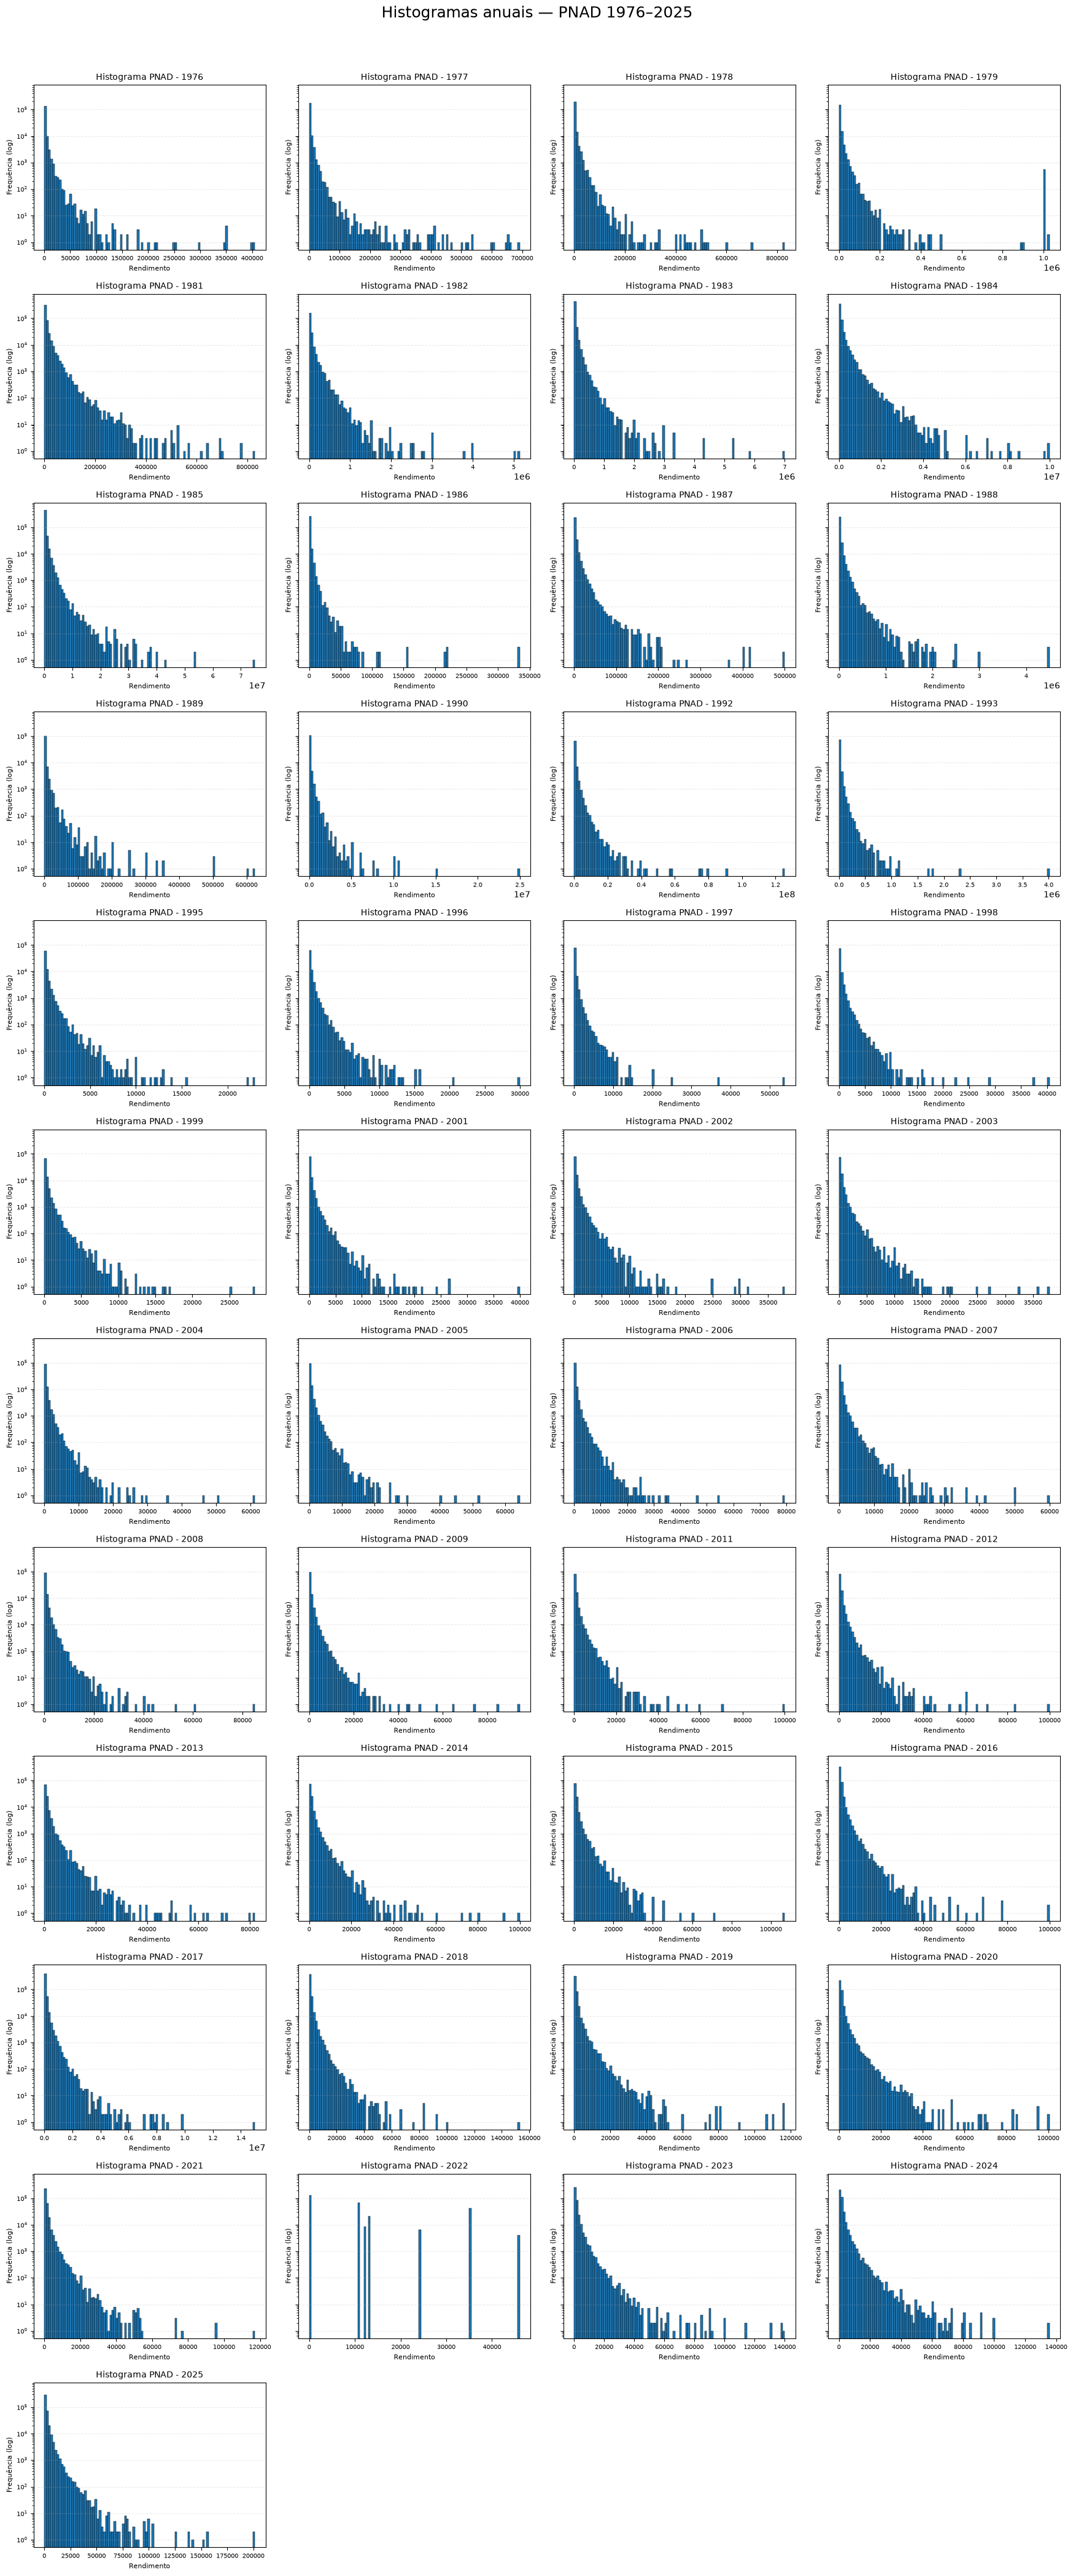

In [29]:
histograms = plot_histograms(
    df_histograms,
    years,
    FIGURES_PATH / "histograms.png",
    ncols=4,
    figsize=None,
)

## Mean and median income over the years

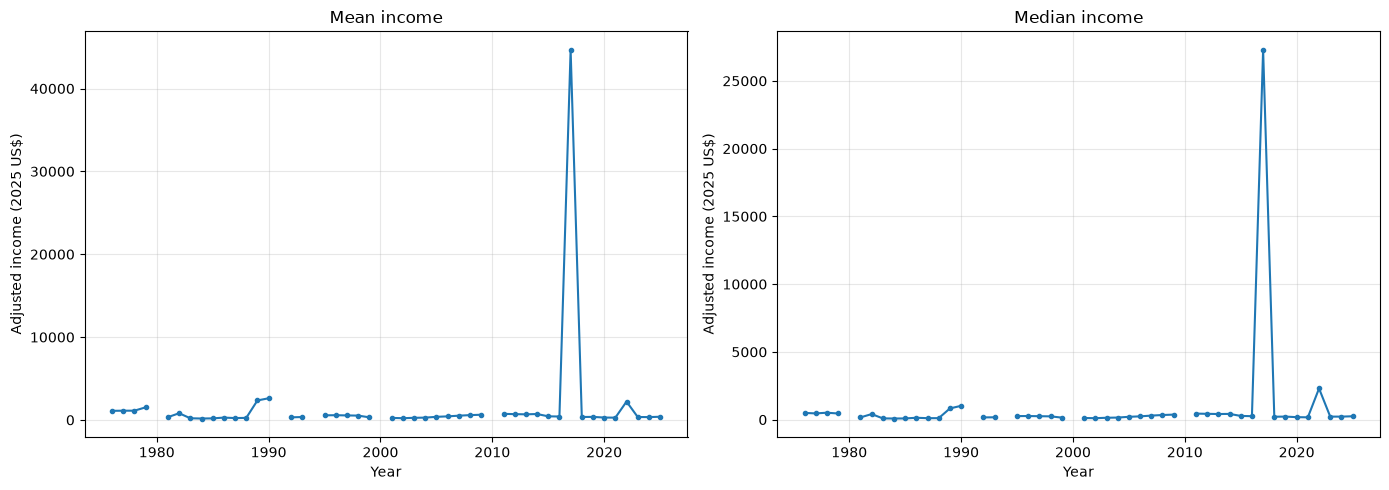

In [30]:
fig_income_mean_median = plot_income_mean_median(
    df_stats_year,
    FIGURES_PATH / "income_mean_median.png",
    ncols=2,
    figsize=(14, 5),
)

## CCDF log-log

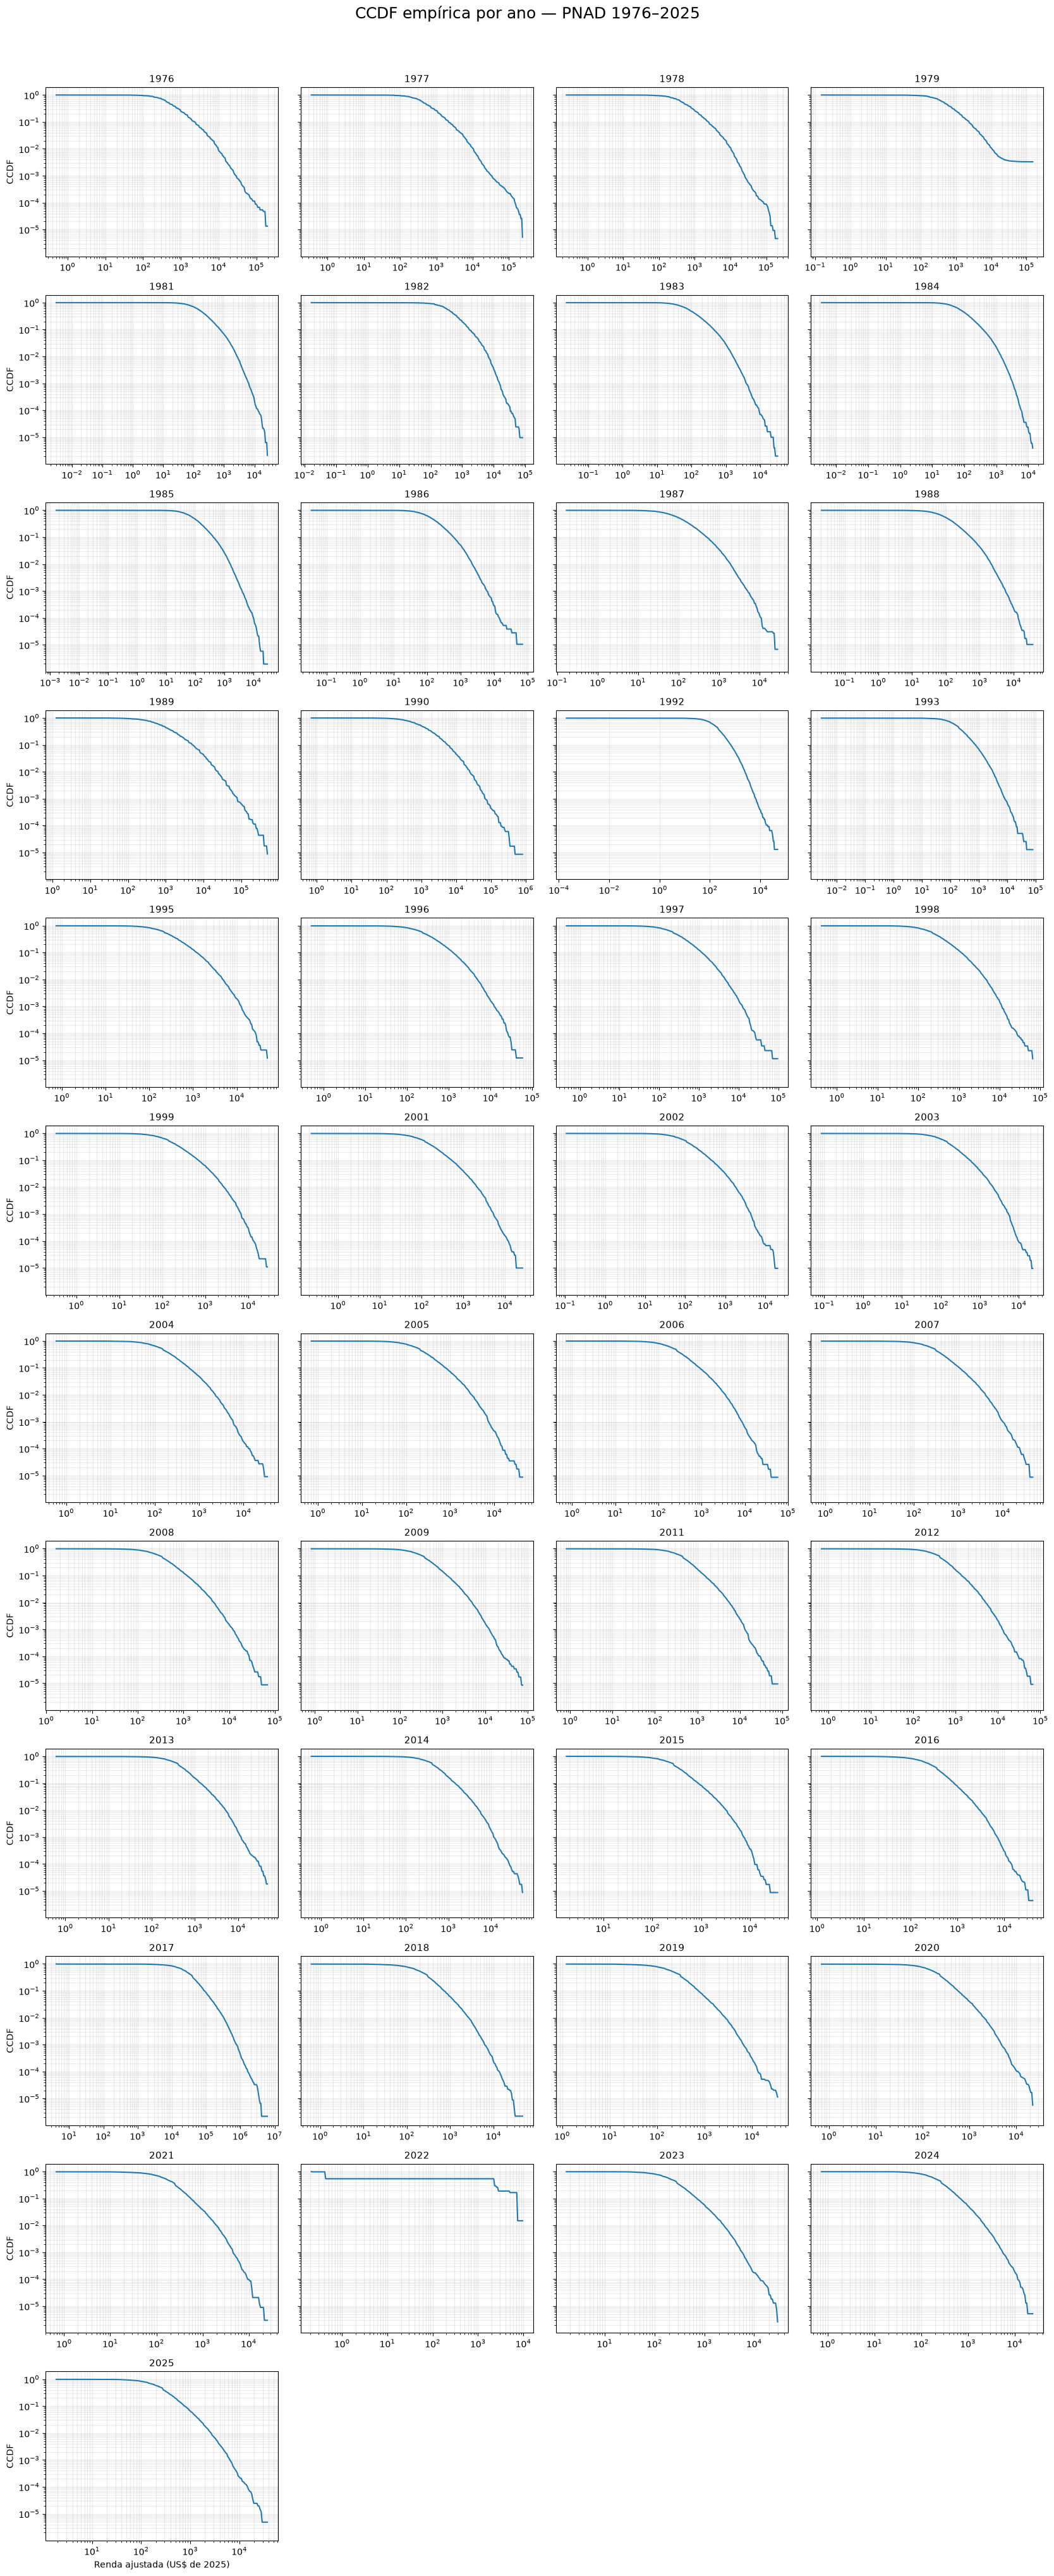

In [31]:
fig_ccdf_log_log = plot_ccdf_loglog(
    df_ccdf,
    years,
    FIGURES_PATH / "ccdf_loglog.png",
    ncols=4,
    figsize=None,
)

## ln[ln(100 × CCDF)]

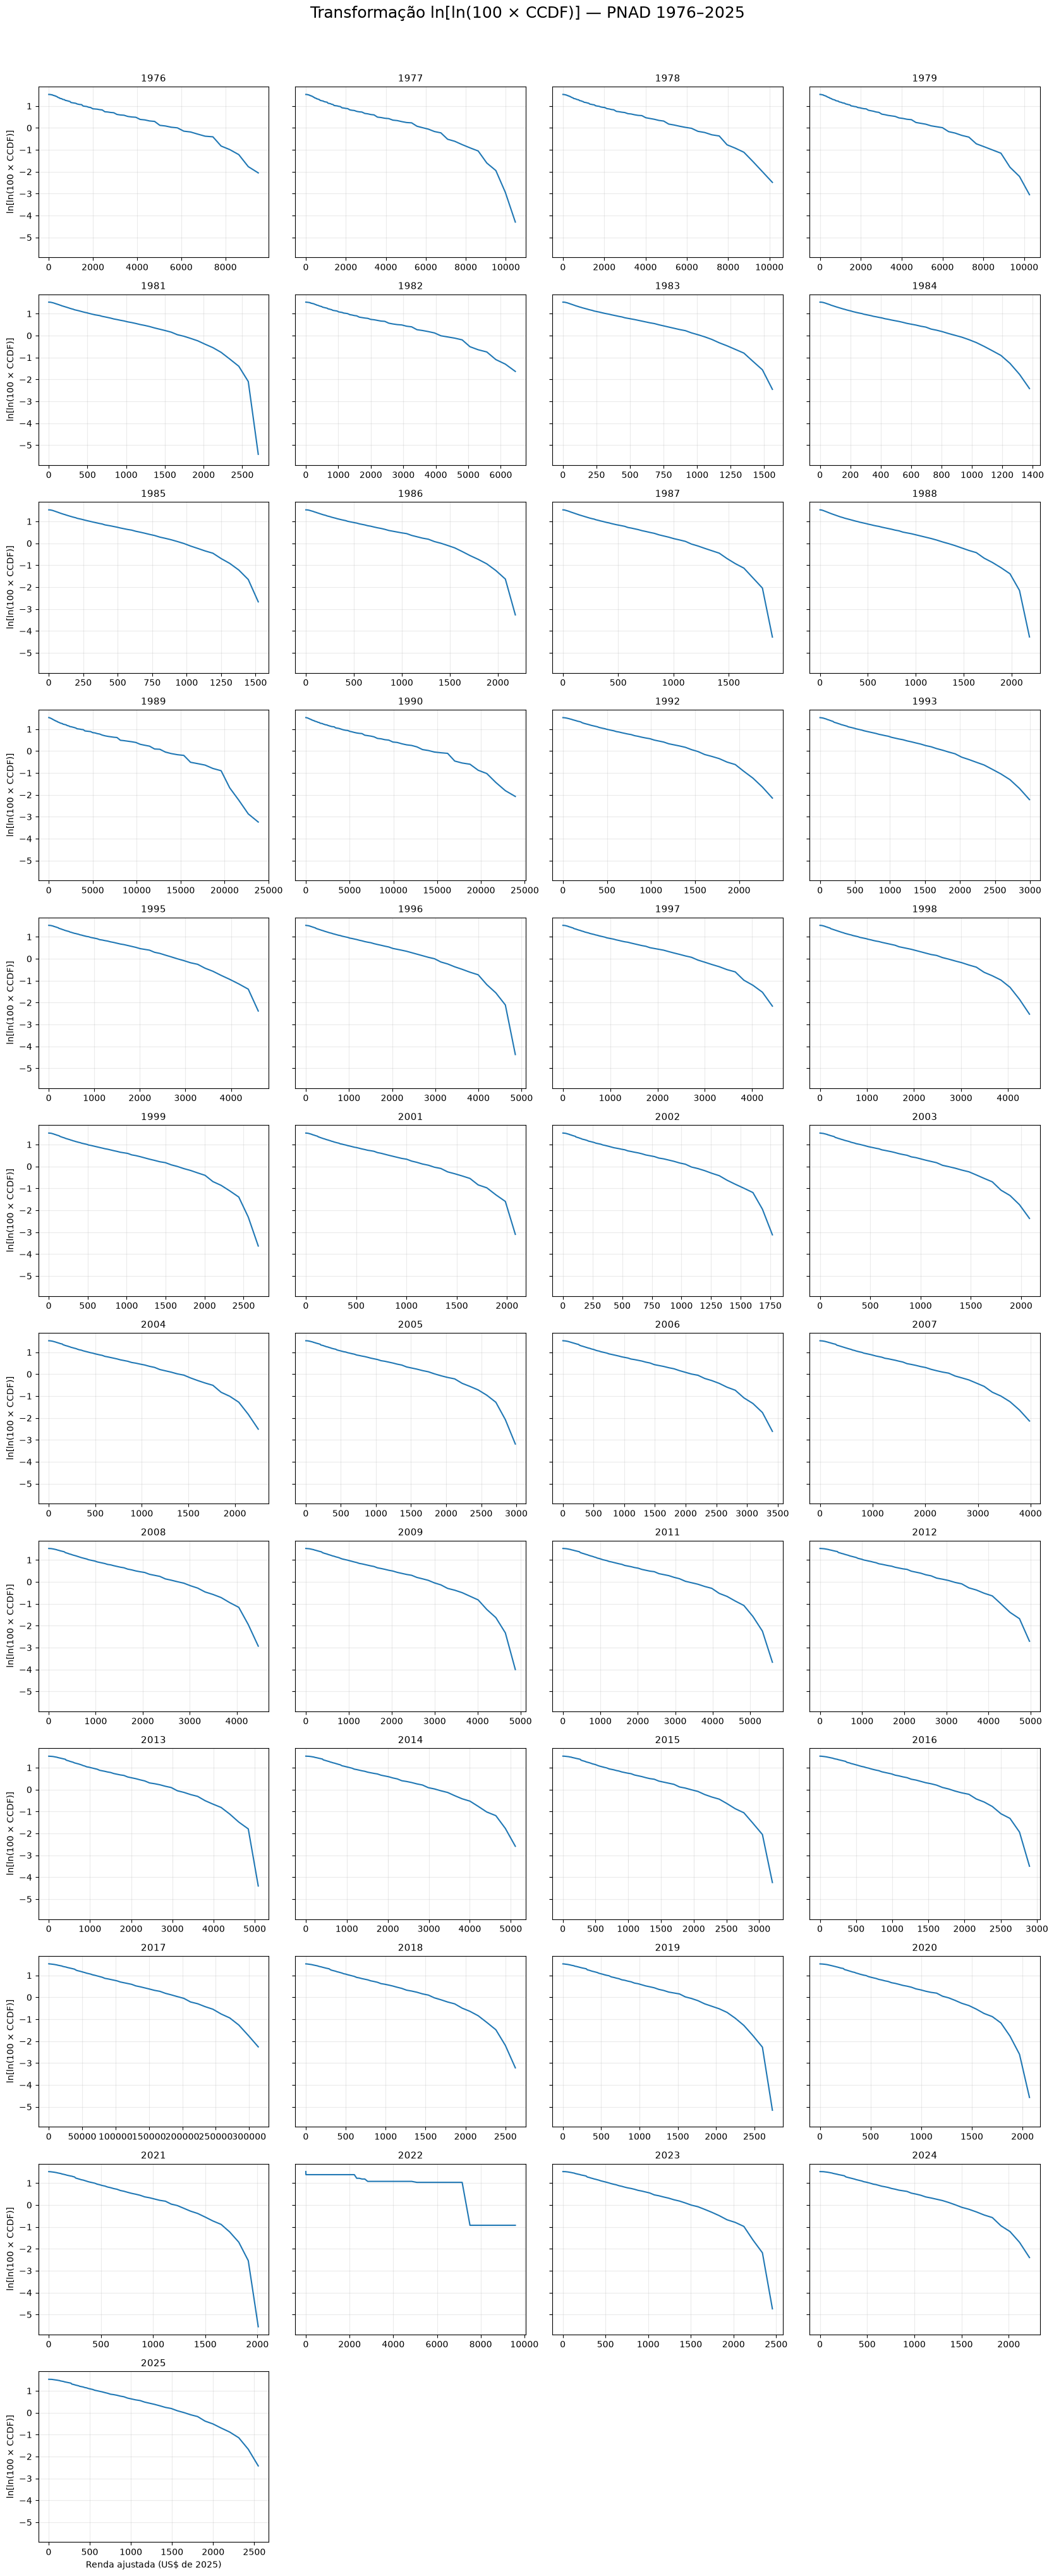

In [32]:
fig_ccdf_lnln = plot_ccdf_lnln(
    df_ccdf,
    years,
    FIGURES_PATH / "ccdf_lnln.png",
    ncols=4,
    figsize=None,
)

## Table stats geometric bins

In [33]:
tb_bins = bins_table(df_bins, n=20)
print("Number of bins:", len(df_bins))
print("Nominal geometric ration:", BIN_RATIO)
tb_bins

Number of bins: 8670
Nominal geometric ration: 1.05


,year,bin_left,bin_right,bin_center_geo,N_bin,mean,geometric_mean,median,std,ccdf
0,1976,0.497592,0.522471,0.509880,10,0.497592,0.497592,0.497592,5.851389e-17,1.000000
1,1976,0.985197,1.034457,1.009527,2,0.995183,0.995183,0.995183,0.000000e+00,0.999933
2,1976,2.881959,3.026057,2.953129,4,2.985549,2.985549,2.985549,0.000000e+00,0.999919
3,1976,4.929128,5.175584,5.050853,8,4.975916,4.975916,4.975916,0.000000e+00,0.999892
4,1976,5.434363,5.706082,5.568565,1,5.473507,5.473507,5.473507,NaN,0.999838
5,1976,5.706082,5.991386,5.846994,1,5.971099,5.971099,5.971099,NaN,0.999832
6,1976,7.282567,7.646695,7.462410,5,7.463874,7.463874,7.463874,0.000000e+00,0.999825
7,1976,8.852005,9.294606,9.070606,1,8.956648,8.956648,8.956648,NaN,0.999791
8,1976,9.759336,10.247303,10.000343,31,9.951832,9.951832,9.951832,0.000000e+00,0.999784
9,1976,10.247303,10.759668,10.500361,1,10.449423,10.449423,10.449423,NaN,0.999575


## Lorenz curve with G, P, k e Z

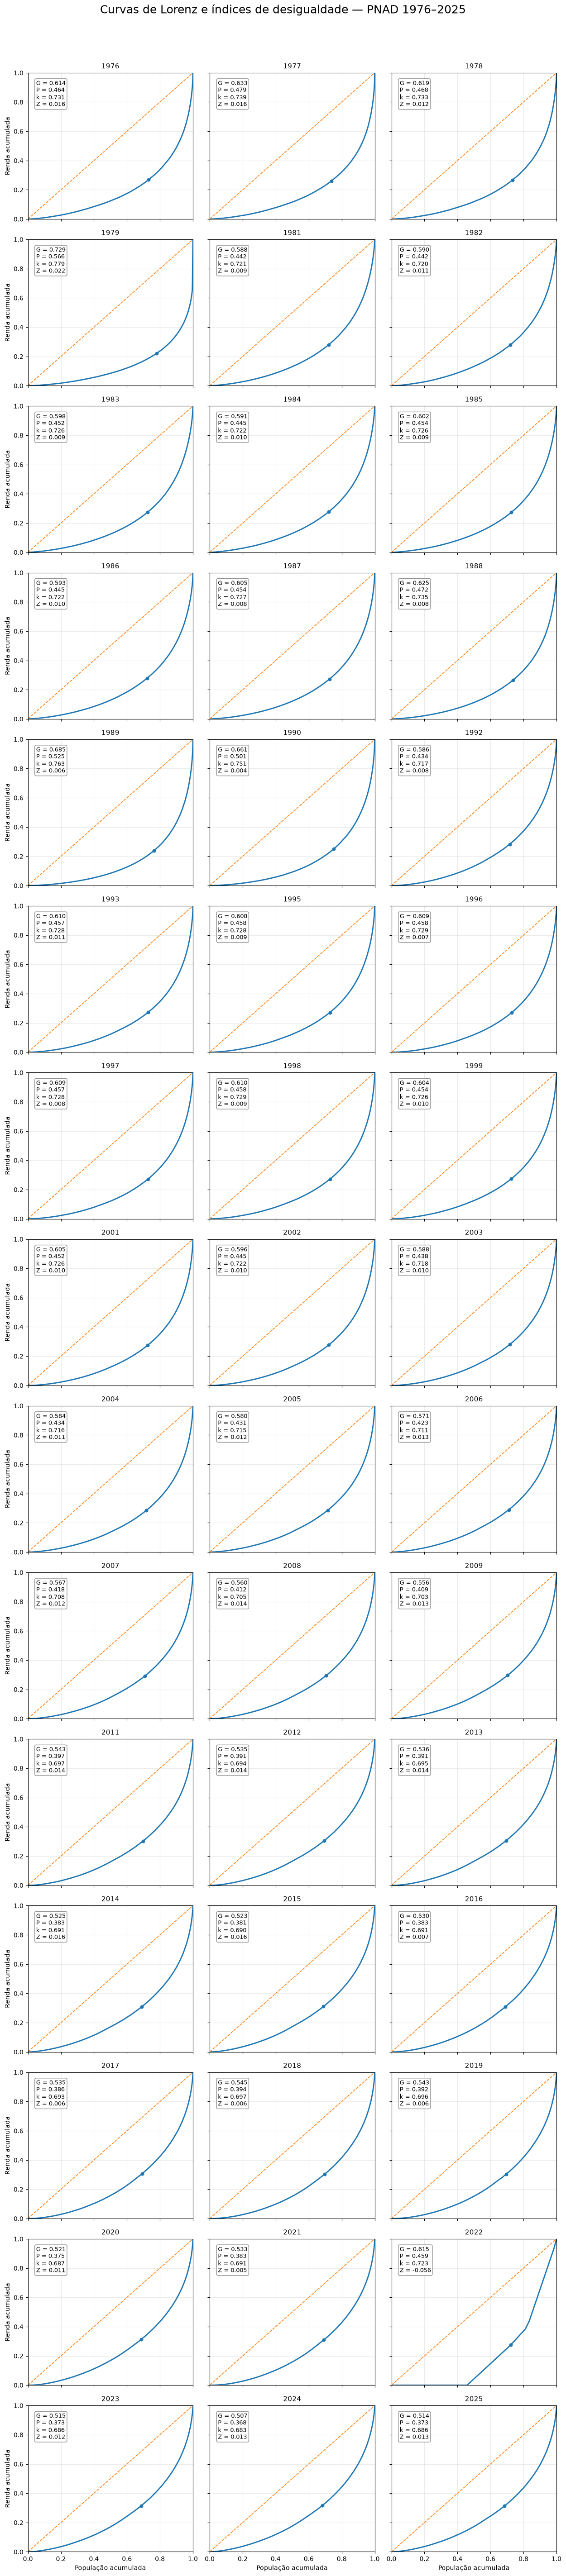

In [34]:
fig_lorenz_gpkz = plot_lorenz_indices(
    df_lorenz,
    df_stats_year,
    years,
    FIGURES_PATH / "lorenz_indices.pdf",
    ncols=3,
    figsize=None,
)

## Lorenz curve — detailed inequality geometry

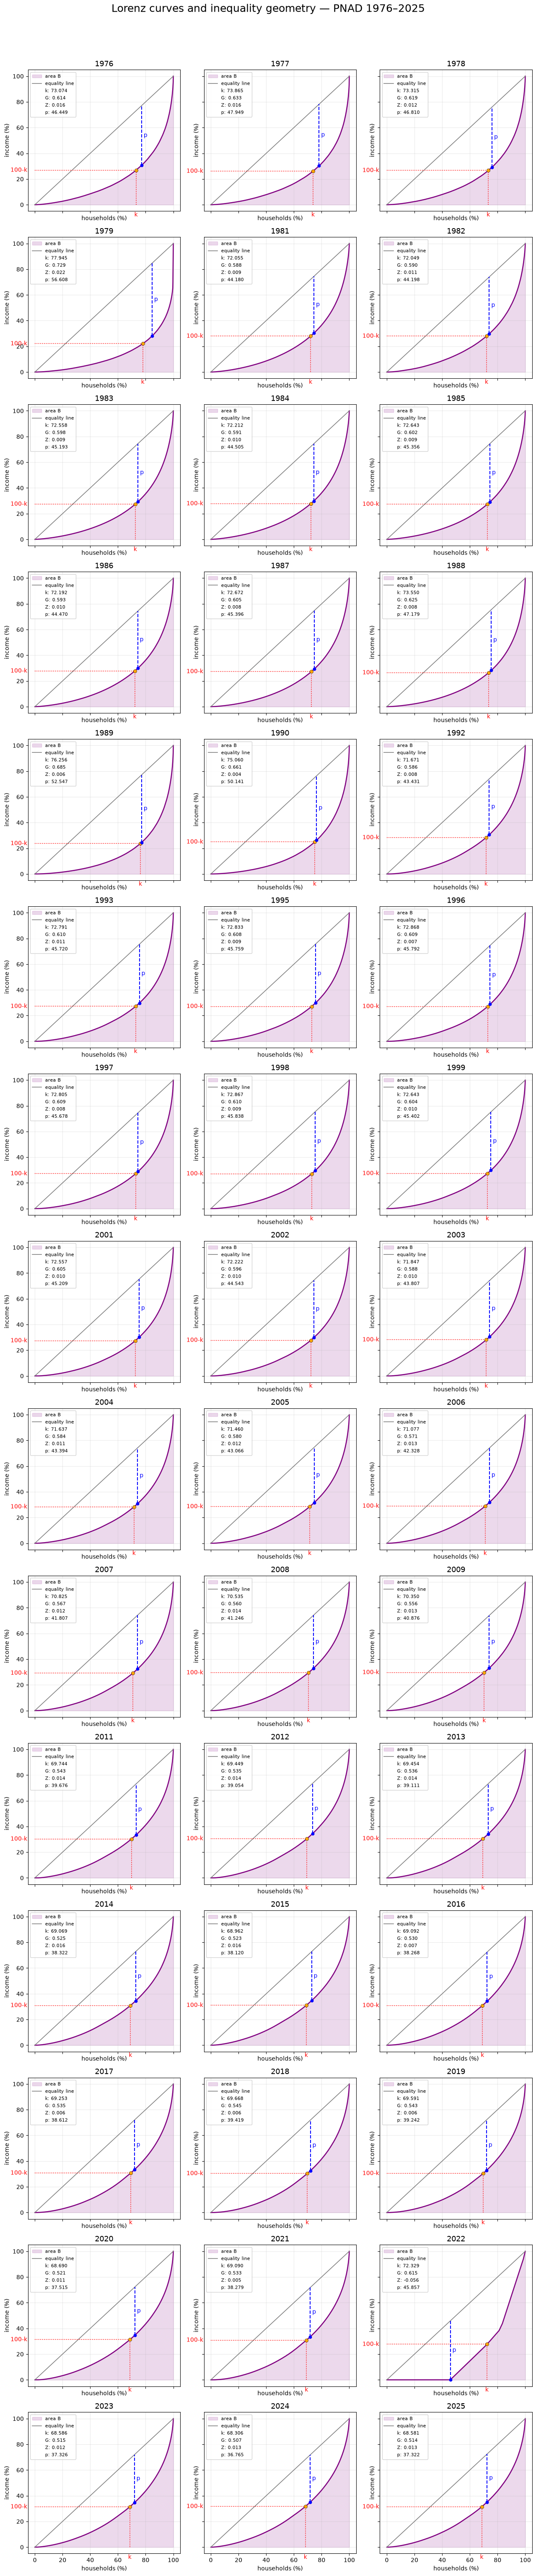

In [35]:
fig_lorenz_geometry = plot_lorenz_indices_pretty(
    df_lorenz,
    df_stats_year,
    years,
    FIGURES_PATH / "lorenz_indices_pretty.pdf",
    ncols=3,
    figsize=None,
)

## Top income concentration

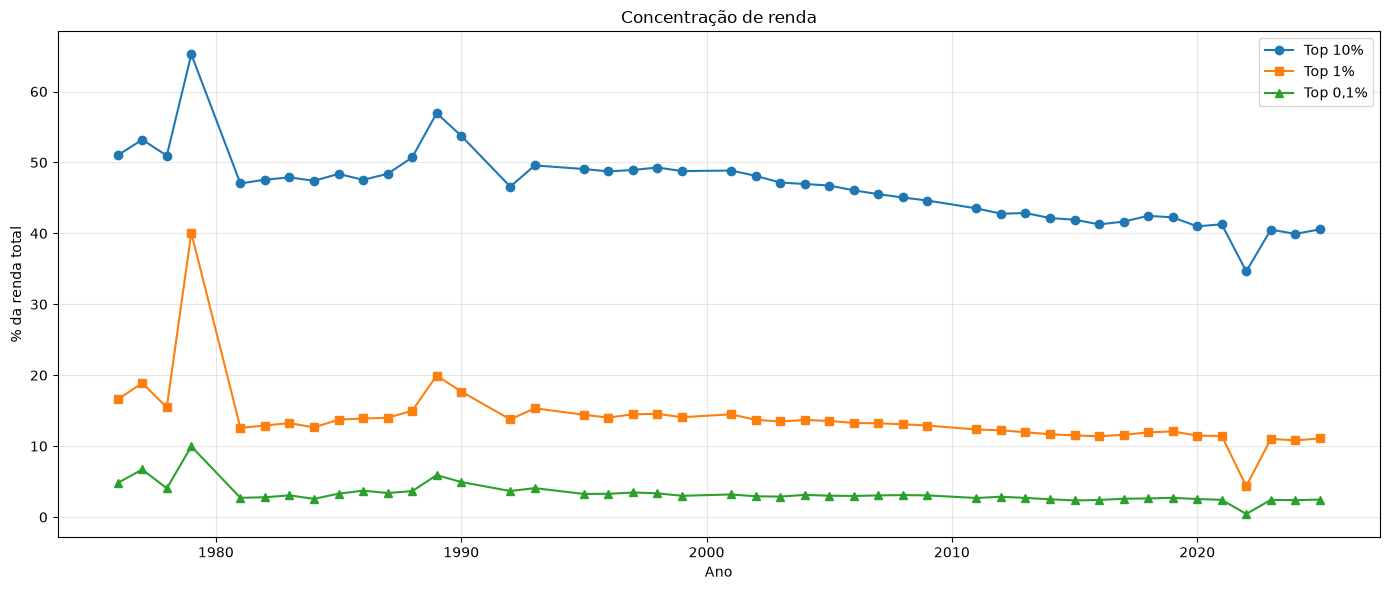

In [36]:
fig_top_income = plot_top_shares(
    df_stats_year,
    FIGURES_PATH / "inequality_top_shares.png",
    figsize=(14, 6),
)

## Inequality index over the years

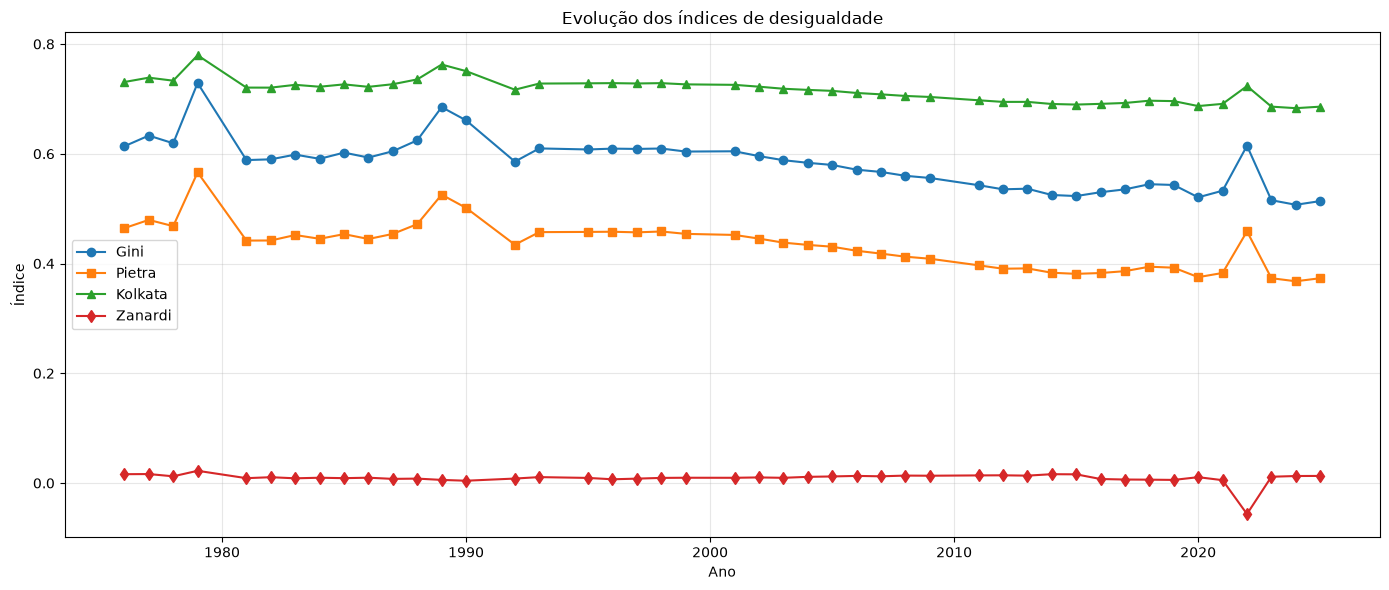

In [37]:
fig_ineq_gpkz = plot_inequality_indices(
    df_stats_year,
    FIGURES_PATH / "inequality_indices.png",
    figsize=(14, 6),
)

## Inequality indices over the years — 2x2

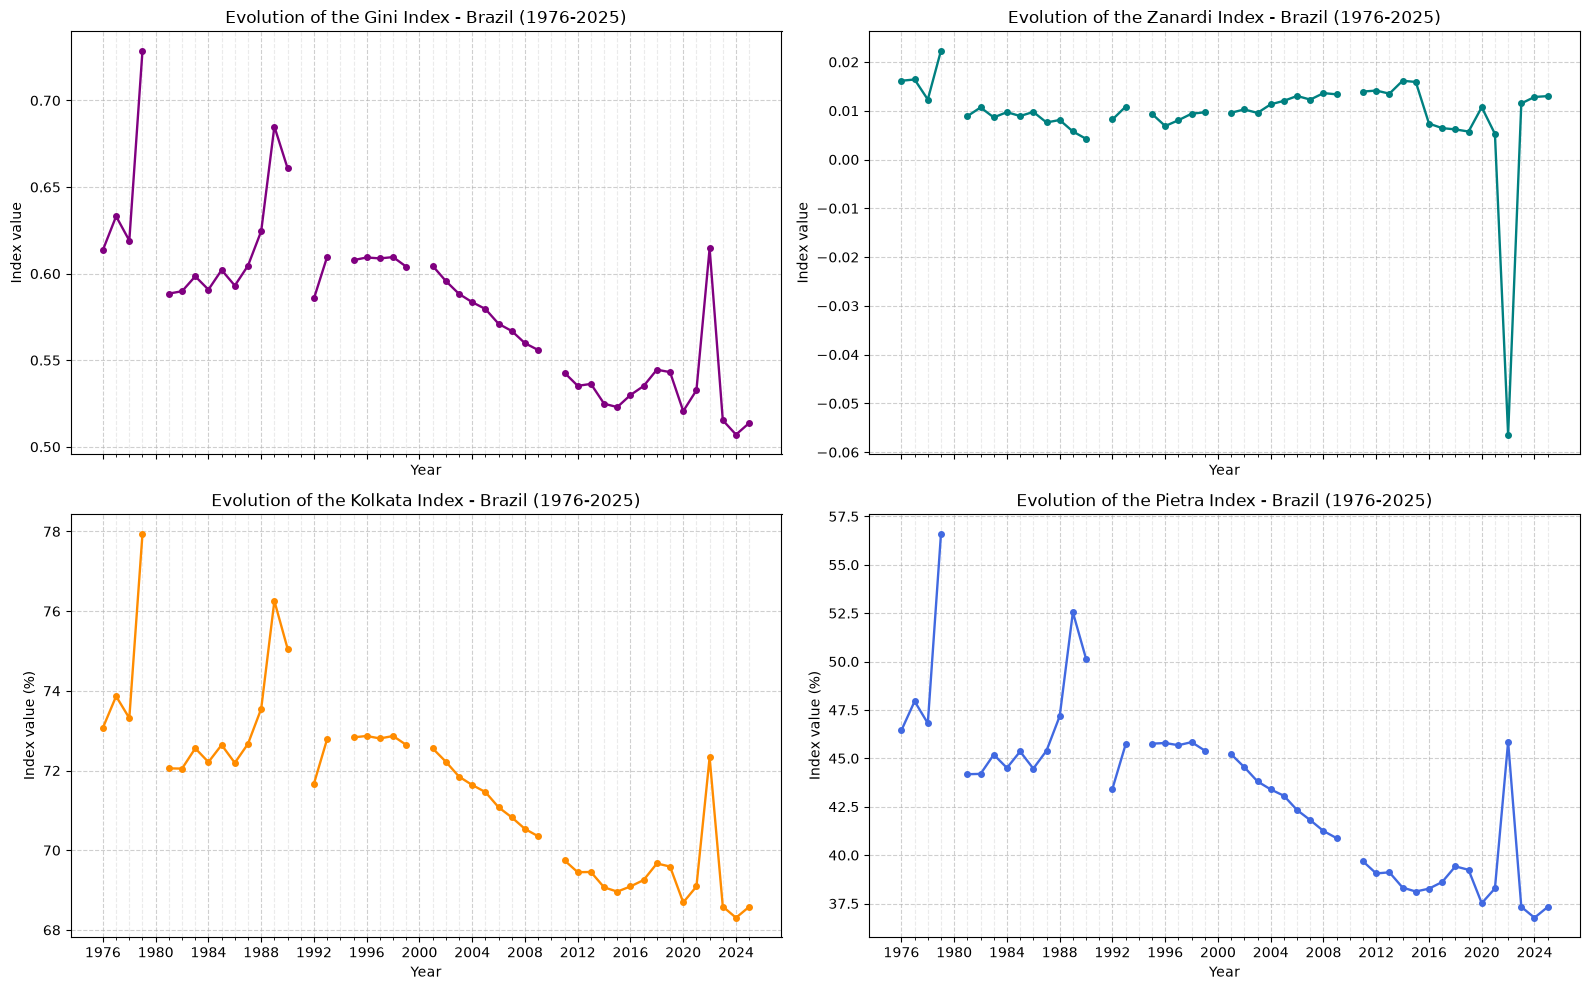

In [38]:
fig_ineq_2x2 = plot_inequality_indices_grid(
    df_stats_year,
    FIGURES_PATH / "inequality_indices_2x2.png",
    ncols=2,
    figsize=(16, 10),
)

## External Gini index validation

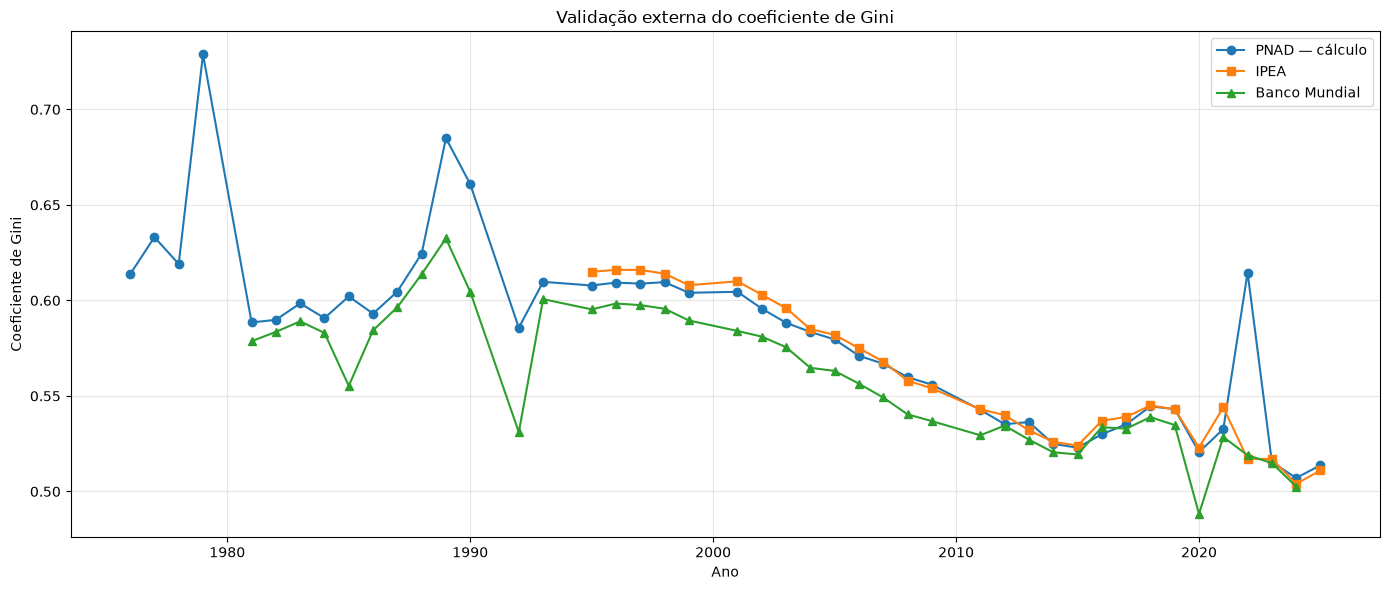

In [39]:
fig_gini_external = plot_gini_validation(
    df_gini_validation,
    FIGURES_PATH / "gini_validation.png",
    figsize=(14, 6),
)

## Gompertz regime fits

Annual least-squares fits of the Gompertz body in the transformed space \(\ln[\ln(F)]\), with empirical points, fitted line, and selected cutoff for each year.

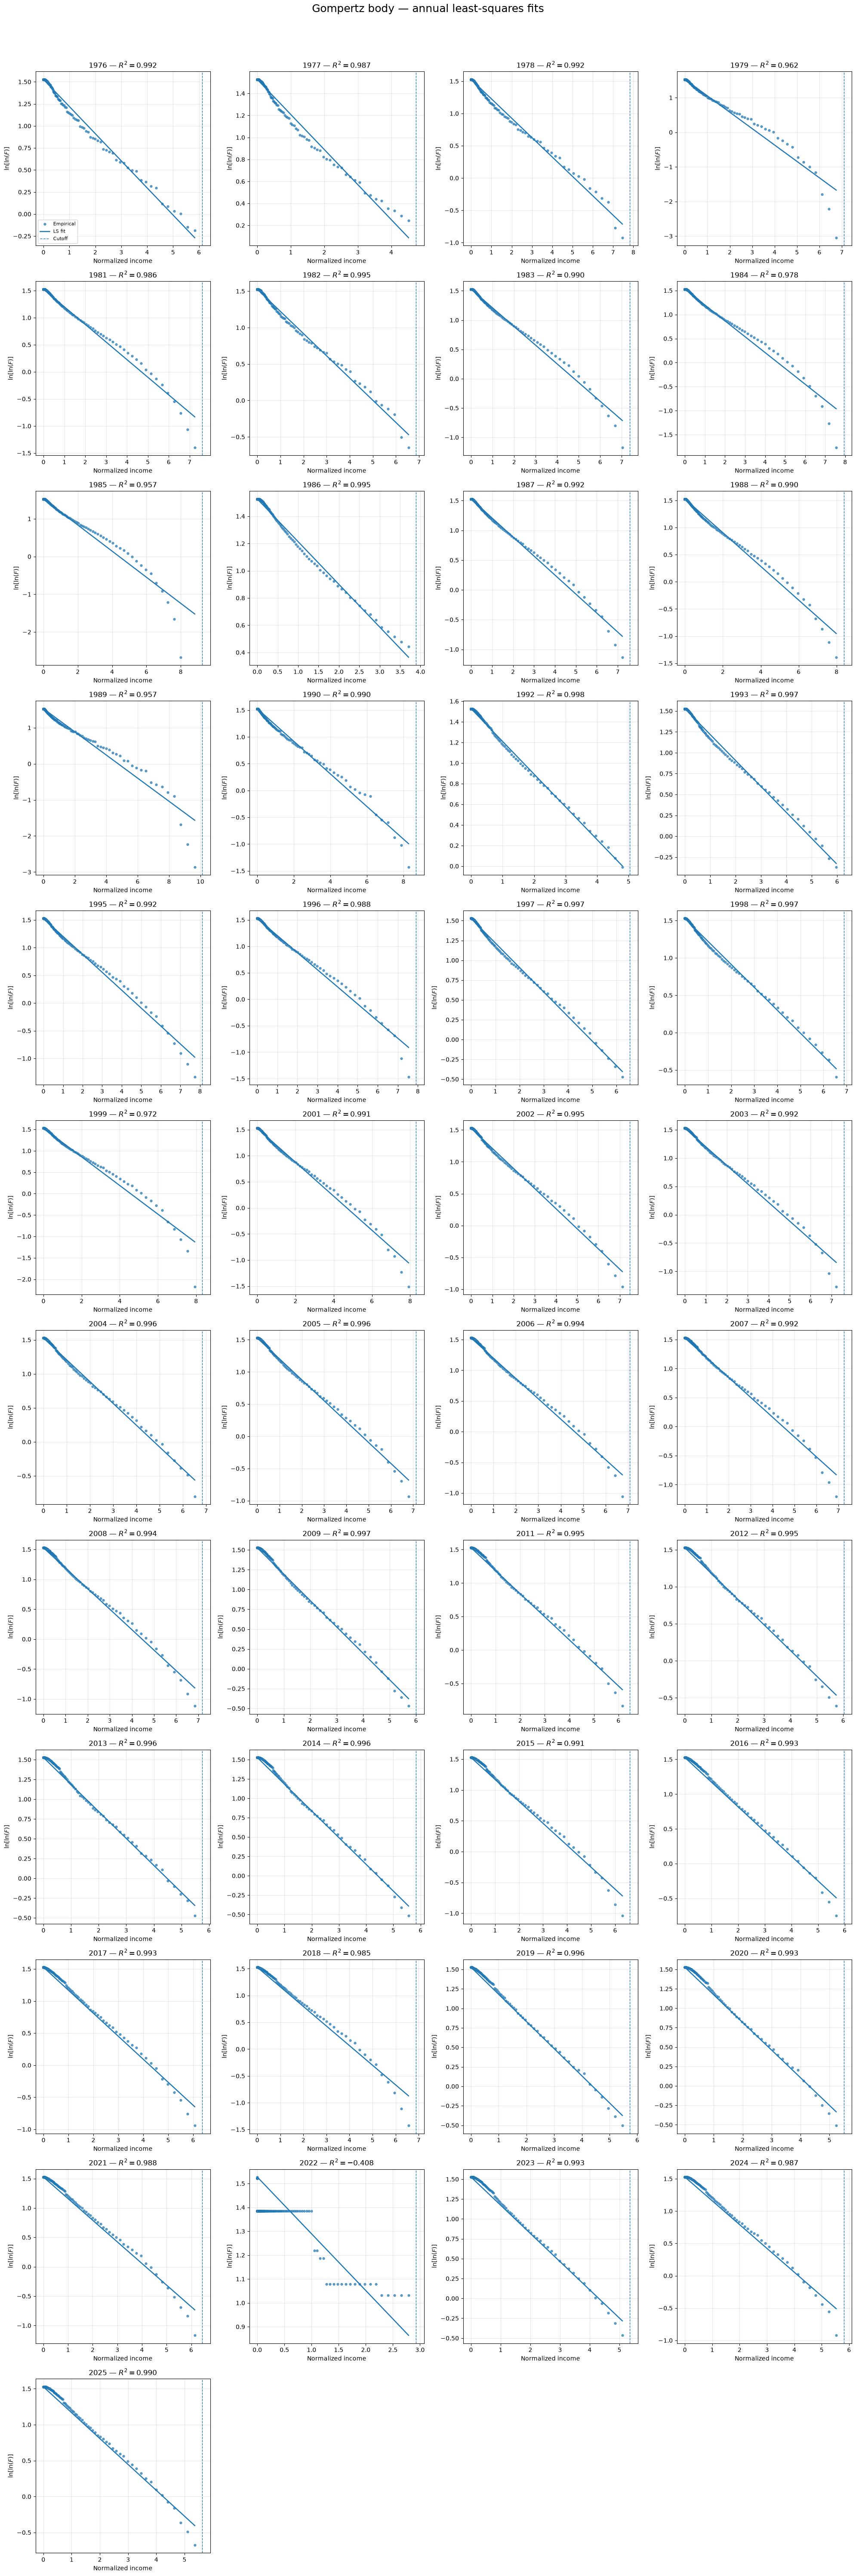

In [40]:
fig_gomp_regime = plot_gompertz_regime_fits(df_regime_curves, 
                                            df_regime_fits, years,
                                            FIGURES_PATH / "gompertz_regime_fits.png",
                                            ncols=4,
                                            figsize=(20, 60),
                                            )

## Pareto regime fits

Annual least-squares fits of the Pareto tail in log-log scale, showing the empirical CCDF, fitted power-law tail, selected cutoff, and estimated Pareto exponent \(\alpha\) for each year.

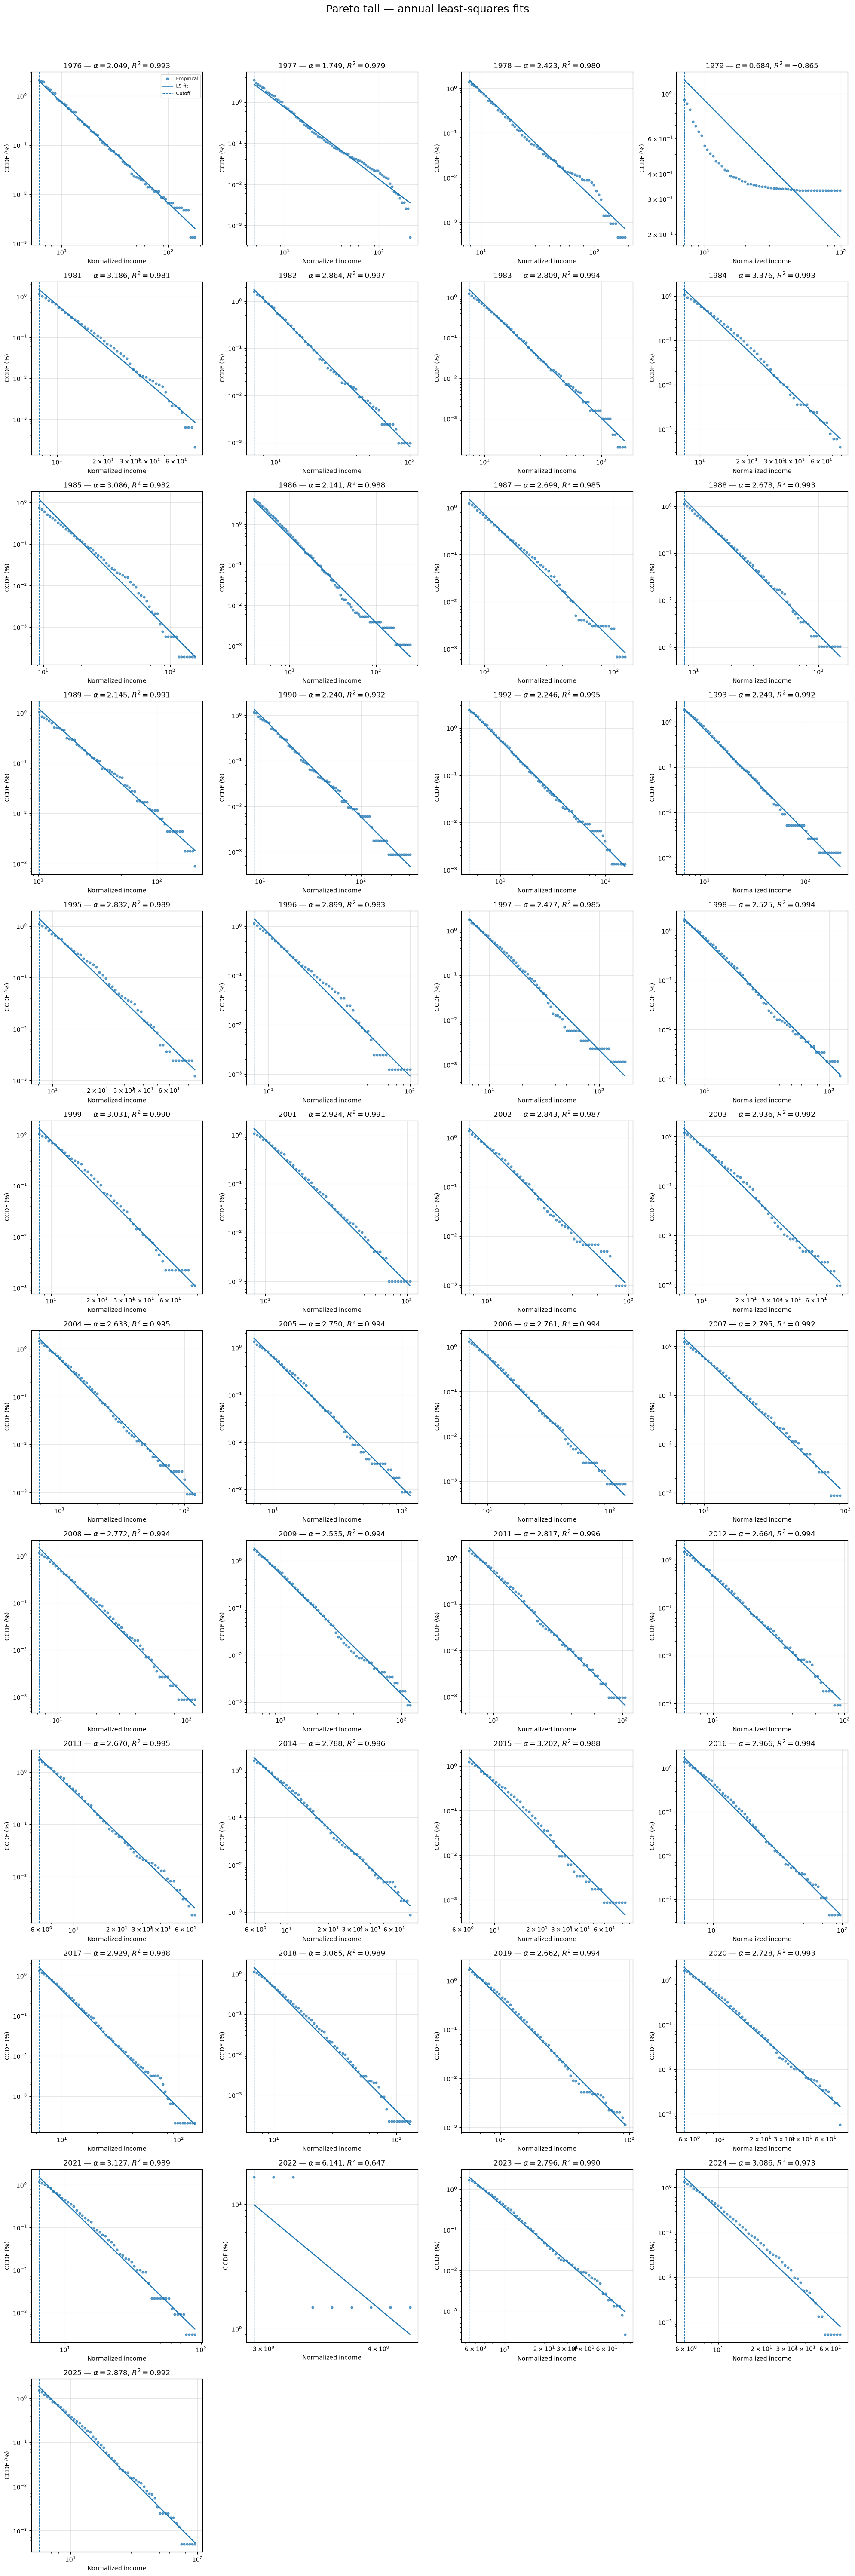

In [41]:
fig_pareto_regime = plot_pareto_regime_fits(
    df_regime_curves,
    df_regime_fits,
    years,
    FIGURES_PATH / "pareto_regime_fits.png",
    ncols=4,
    figsize=(20, 60),
)